# **Notebook 2 - Gene Classification, Literature Evidence & IPA Annotation**
## **AD Cross-Species Transcriptomics Pipeline**

**What this notebook does:**

| Step | Description |
|---|---|
| 1 | Load meta-significant genes from NB1+2 |
| 2 | Query Open Targets — multi-evidence association scores |
| 3 | Query PubMed — count papers per gene + "atopic dermatitis" |
| 4 | **Fetch top PubMed papers per Known gene (PMID + title + URL)** |
| 5 | Classify genes: Known / Novel_Supported / Novel_Unexplored |
| 6 | Annotate IPA tables with novel gene flags |
| 7 | Save classification tables + literature evidence Excel |

**Figures exported:** PNG (300 DPI) · JPEG (300 DPI) · PDF (vector)  
**Reads from:** `Results/meta_summary/`  
**Writes to:** `Results/`

## **Step 0 - Mount Drive**


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


## **Step 1 - Setup**


In [ ]:
!pip install -q openpyxl requests matplotlib seaborn

import pandas as pd
import numpy as np
import os, json, time, re, requests, warnings
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
import seaborn as sns
import openpyxl
from openpyxl import Workbook
from openpyxl.styles import PatternFill, Font, Alignment
warnings.filterwarnings('ignore')

# ── Publication-quality settings (300 DPI, large clear labels) ───────────────
matplotlib.rcParams.update({
    'font.family'           : 'DejaVu Sans',
    'font.size'             : 14,
    'axes.labelsize'        : 15,
    'axes.titlesize'        : 16,
    'axes.titleweight'      : 'bold',
    'axes.labelweight'      : 'bold',
    'xtick.labelsize'       : 13,
    'ytick.labelsize'       : 13,
    'legend.fontsize'       : 12,
    'legend.title_fontsize' : 13,
    'axes.spines.top'       : False,
    'axes.spines.right'     : False,
    'axes.linewidth'        : 1.2,
    'xtick.major.width'     : 1.2,
    'ytick.major.width'     : 1.2,
    'figure.facecolor'      : 'white',
    'axes.facecolor'        : 'white',
    'savefig.dpi'           : 300,
    'figure.dpi'            : 150,   # screen preview
})
DPI = 300

# ── Paths ─────────────────────────────────────────────────────────────────────
BASE       = '/content/drive/MyDrive/Research/Atopic Dermatitis/Research Paper'
RES        = os.path.join(BASE, 'Results')
META       = os.path.join(RES,  'meta_summary')
IPA_DIR    = os.path.join(BASE, 'IPA')
INPUT_DATA = os.path.join(BASE, 'Input Data')

# NB02 subfolder structure
NB02       = os.path.join(RES,  'NB02')
NB02_FIG   = os.path.join(NB02, 'Figures')
NB02_TAB   = os.path.join(NB02, 'Tables')
NB02_SUP   = os.path.join(NB02, 'Supplementary_Files')
IPA_OUT    = os.path.join(NB02_TAB, 'IPA_Annotated')

# NB01 subfolder (for loading meta-analysis files)
NB01_TAB   = os.path.join(RES, 'NB01', 'Tables')

FIG_DIR    = NB02_FIG   # string path used with os.path.join throughout

for d in [NB02_FIG, NB02_TAB, NB02_SUP, IPA_OUT]:
    os.makedirs(d, exist_ok=True)

# ── Thresholds ────────────────────────────────────────────────────────────────
AD_EFO_ID             = 'EFO_0000274'
OPENTARGETS_THRESHOLD = 0.05
GENECARD_SCORE_MIN    = 1.0
PUBMED_THRESHOLD      = 1
NCBI_EMAIL            = 'sonalikaray97@gmail.com'

# ── Colour palette ────────────────────────────────────────────────────────────
CLR = {'Known':'#2166AC','Novel_Supported':'#F4A261',
       'Novel_Unexplored':'#D62828','Up':'#D73027','Down':'#4575B4'}

SUBCAT_COLORS = {
    'Known_OT_CTD'       : '#1B4F72',
    'Known_OpenTargets'  : '#2471A3',
    'Known_CTD_Direct'   : '#1ABC9C',
    'Known_CTD_Inferred' : '#76D7C4',
    'Known_GeneCards'    : '#F39C12',
    'Known_PubMed'       : '#E67E22',
    'Novel_Supported'    : '#E84855',
    'Novel_Unexplored'   : '#AAAAAA',
}

# ── Save figure helper ────────────────────────────────────────────────────────
def save_fig(fig, name):
    for ext in ['png', 'svg', 'pdf']:
        path = os.path.join(FIG_DIR, f'{name}.{ext}')
        fig.savefig(path, dpi=DPI if ext == 'png' else None,
                    bbox_inches='tight', facecolor='white',
                    format=ext)
    print(f'  Saved: {name}.png / .svg / .pdf')
    plt.show()
    plt.close(fig)

print('NB02 setup complete.')
print(f'  NB02/Figures/             -> {NB02_FIG}')
print(f'  NB02/Tables/              -> {NB02_TAB}')
print(f'  NB02/Supplementary_Files/ -> {NB02_SUP}')


NB02 setup complete.
  NB02/Figures/             -> /content/drive/MyDrive/Research/Atopic Dermatitis/Research Paper/Results/NB02/Figures
  NB02/Tables/              -> /content/drive/MyDrive/Research/Atopic Dermatitis/Research Paper/Results/NB02/Tables
  NB02/Supplementary_Files/ -> /content/drive/MyDrive/Research/Atopic Dermatitis/Research Paper/Results/NB02/Supplementary_Files


## **Step 2 - Load Meta-Significant Genes**


In [ ]:
# ── Step 2 — Load Meta-Significant Genes ─────────────────────────────────────
#
# File mapping (matches what NB1 actually saved):
#   LN  → meta_Human_Lesional_vs_Normal.csv          (Fisher+Stouffer, 8 datasets)
#   LNL → meta_Human_Lesional_vs_Nonlesional.csv     (Fisher+Stouffer, 8 datasets)
#   NLN → Human_Nonlesional_vs_Normal_vote_summary.csv  ← only 1 dataset, no meta
#   Canine → meta_Canine_AD_vs_Healthy.csv
# ─────────────────────────────────────────────────────────────────────────────

def load_meta(fname, fallback_fname=None):
    """
    Try META folder first, then RES folder, then NB01_TAB folder.
    If fallback_fname is given, try that if the primary is missing.
    Returns an empty DataFrame (never crashes) if nothing is found.
    """
    for candidate in [fname] + ([fallback_fname] if fallback_fname else []):
        for folder in [META, RES, NB01_TAB]: # Added NB01_TAB to search paths
            path = os.path.join(folder, candidate)
            if os.path.exists(path):
                df = pd.read_csv(path)
                df['Gene_Symbol'] = df['Gene_Symbol'].astype(str).str.strip().str.upper()
                print(f'  ✓ Loaded {candidate}  ({len(df)} rows)  from {os.path.basename(folder)}/')
                return df
    print(f'  ⚠ Not found: {fname}' + (f' (also tried {fallback_fname})' if fallback_fname else ''))
    return pd.DataFrame()

def get_sig(df, source_label=''):
    """Return significant rows. Handles meta CSVs and vote_summary CSVs."""
    if df.empty:
        return df
    # Fisher+Stouffer meta results
    if 'meta_significant' in df.columns:
        out = df[df['meta_significant'] == True].copy()
        print(f'    {source_label}: {len(out)} meta-significant genes (meta_significant flag)')
        return out
    # Stouffer padj only (enriched tables)
    for col in ['Stouffer_padj', 'stouffer_padj']:
        if col in df.columns:
            out = df[df[col] < 0.05].copy()
            print(f'    {source_label}: {len(out)} genes (Stouffer_padj < 0.05)')
            return out
    # Vote-summary fallback (NLN — single dataset, no formal meta)
    # Use min_p_value < 0.05 as the significance criterion
    for col in ['min_p_value', 'p_value', 'p.value']:
        if col in df.columns:
            out = df[df[col] < 0.05].copy()
            print(f'    {source_label}: {len(out)} genes ({col} < 0.05) '
                  f'[single-dataset, no formal meta]')
            return out
    # Last resort — return everything
    print(f'    {source_label}: no significance column found, returning all {len(df)} rows')
    return df.copy()

def norm_fc_col(df):
    """Normalise all log2FC column name variants to median_log2FC."""
    for c in list(df.columns):
        cl = c.lower()
        if ('median' in cl and 'log' in cl) or cl == 'median_log2fc':
            if c != 'median_log2FC':
                df.rename(columns={c: 'median_log2FC'}, inplace=True)
    return df

# ── Load ──────────────────────────────────────────────────────────────────────
print('Loading meta-analysis results...\n')

meta_LN  = load_meta('meta_Human_Lesional_vs_Normal.csv',
                     'meta_Human_Lesional_vs_Normal_enriched.csv')

meta_LNL = load_meta('meta_Human_Lesional_vs_Nonlesional.csv',
                     'meta_Human_Lesional_vs_Nonlesional_enriched.csv')

# NLN: no formal meta CSV exists — fall back to vote_summary
meta_NLN = load_meta('meta_Human_Nonlesional_vs_Normal.csv',           # will not exist
                     'Human_Nonlesional_vs_Normal_vote_summary.csv')   # ← this one exists

meta_canine = load_meta('meta_Canine_AD_vs_Healthy.csv',
                        'meta_Canine_AD_vs_Healthy_enriched.csv')

# ── Filter to significant genes ───────────────────────────────────────────────
print()
sig_LN     = get_sig(meta_LN,     'Human LN')
sig_LNL    = get_sig(meta_LNL,    'Human LNL')
sig_NLN    = get_sig(meta_NLN,    'Human NLN')
sig_canine = get_sig(meta_canine, 'Canine AD')

# Normalise FC column name across all tables
for df in [sig_LN, sig_LNL, sig_NLN, sig_canine]:
    norm_fc_col(df)

# ── Gene lists ────────────────────────────────────────────────────────────────
def gene_set(df):
    return set(df['Gene_Symbol']) if not df.empty and 'Gene_Symbol' in df.columns else set()

human_genes  = sorted(gene_set(sig_LN) | gene_set(sig_LNL) | gene_set(sig_NLN))
canine_genes = sorted(gene_set(sig_canine))
all_genes    = sorted(set(human_genes) | set(canine_genes))

print(f'\nGene lists ready:')
print(f'  Human LN   : {len(sig_LN)} genes')
print(f'  Human LNL  : {len(sig_LNL)} genes')
print(f'  Human NLN  : {len(sig_NLN)} genes  (vote-summary; single dataset)')
print(f'  Canine AD  : {len(sig_canine)} genes')
print(f'  Total unique: {len(all_genes)} genes across all comparisons')


Loading meta-analysis results...

  ✓ Loaded meta_Human_Lesional_vs_Normal.csv  (181 rows)  from meta_summary/
  ✓ Loaded meta_Human_Lesional_vs_Nonlesional.csv  (20 rows)  from meta_summary/
  ✓ Loaded Human_Nonlesional_vs_Normal_vote_summary.csv  (157 rows)  from meta_summary/
  ✓ Loaded meta_Canine_AD_vs_Healthy.csv  (43 rows)  from meta_summary/

    Human LN: 176 meta-significant genes (meta_significant flag)
    Human LNL: 17 meta-significant genes (meta_significant flag)
    Human NLN: 157 genes (min_p_value < 0.05) [single-dataset, no formal meta]
    Canine AD: 41 meta-significant genes (meta_significant flag)

Gene lists ready:
  Human LN   : 176 genes
  Human LNL  : 17 genes
  Human NLN  : 157 genes  (vote-summary; single dataset)
  Canine AD  : 41 genes
  Total unique: 357 genes across all comparisons


In [ ]:
print(f'Listing contents of {META}:')
!ls -F "{META}"
print(f'Listing contents of {RES}:')
!ls -F "{RES}"

Listing contents of /content/drive/MyDrive/Research/Atopic Dermatitis/Research Paper/Results/meta_summary:
Canine_AD_vs_Healthy_vote_summary.csv
cross_species_ortholog_shared.csv
Human_Lesional_vs_Nonlesional_vote_summary.csv
Human_Lesional_vs_Normal_vote_summary.csv
Human_Nonlesional_vs_Normal_vote_summary.csv
meta_analysis_summary.csv
meta_Canine_AD_vs_Healthy.csv
meta_Canine_AD_vs_Healthy_enriched.csv
meta_Human_Lesional_vs_Nonlesional.csv
meta_Human_Lesional_vs_Nonlesional_enriched.csv
meta_Human_Lesional_vs_Normal.csv
meta_Human_Lesional_vs_Normal_enriched.csv
Listing contents of /content/drive/MyDrive/Research/Atopic Dermatitis/Research Paper/Results:
bootstrap_stability.csv		      enrichment_gprofiler_Human_Known.csv
clf_canine_final.csv		      enrichment_gprofiler_human_novel.csv
clf_human_LN_final.csv		      enrichment_gprofiler_Human_Novel.csv
clf_human_LNL_final.csv		      lodo_rank_correlation.csv
clf_human_NLN_final.csv		      meta_summary/
common_genes.csv		      NB01/
co

## **Step 3a - Open Targets Query**


In [ ]:
# Step 3a: Load Open Targets from file
OT_FILE = os.path.join(INPUT_DATA, 'OT_Atopic_Dermatitis.tsv')
ot_db   = {}

if os.path.exists(OT_FILE):
    ot_df = pd.read_csv(OT_FILE, sep='\t')
    print(f'Open Targets: {ot_df.shape[0]} rows')
    print(f'Columns: {list(ot_df.columns[:8])}')

    sym_col = next((c for c in ot_df.columns
                    if any(k in c.lower() for k in ['symbol','gene','target'])), ot_df.columns[0])
    # OT Platform export uses 'globalScore'; older exports use 'score'
    score_col = next((c for c in ot_df.columns
                      if c.lower() in ['globalscore','score','overall',
                                        'overallassociationscore','association_score']), None)
    genetic_col = next((c for c in ot_df.columns
                        if 'genetic' in c.lower() and 'constraint' not in c.lower()), None)
    drug_col    = next((c for c in ot_df.columns
                        if c.lower() in ['knowndrug','known_drug','drugs']), None)
    lit_col     = next((c for c in ot_df.columns if 'literature' in c.lower()), None)

    print(f'  Gene col   : {sym_col}')
    print(f'  Score col  : {score_col}')

    def safe_float(col, row):
        if col and pd.notna(row.get(col)):
            try: return round(float(row[col]), 4)
            except (ValueError, TypeError): return 0.0
        return 0.0

    for _, row in ot_df.iterrows():
        gene = str(row[sym_col]).strip().upper()
        if not gene or gene in ('NAN', 'NONE', ''): continue
        ot_db[gene] = {
            'OT_score'     : safe_float(score_col, row),
            'OT_genetic'   : safe_float(genetic_col, row),
            'OT_drug'      : safe_float(drug_col, row),
            'OT_literature': safe_float(lit_col, row),
        }

    pd.DataFrame([{'Gene_Symbol':g,**v} for g,v in ot_db.items()]).to_csv(
        os.path.join(NB02_TAB, 'opentargets_AD_raw.csv'), index=False)
    n_thresh = sum(1 for v in ot_db.values() if v['OT_score'] >= OPENTARGETS_THRESHOLD)
    print(f'  {len(ot_db)} genes loaded | {n_thresh} with score >= {OPENTARGETS_THRESHOLD}')
else:
    print(f'  File not found: {OT_FILE}')
    ot_db = {}


Open Targets: 3225 rows
Columns: ['symbol', 'globalScore', 'clinicalPrecedence', 'gwasCredibleSets', 'geneBurden', 'eva', 'genomicsEngland', 'gene2Phenotype']
  Gene col   : symbol
  Score col  : globalScore
  3138 genes loaded | 420 with score >= 0.05


## **Step 3b - CTD Query (Comparative Toxicogenomics Database)**

Atopic Dermatitis **MESH ID: D004485**.
Evidence: DirectEvidence + InferenceScore.


In [ ]:
# Step 3b: Load CTD - ALL genes (DirectEvidence + InferenceScore)
# Classification logic (applied in classify cell):
#   DirectEvidence present                        -> Known (curated expert evidence)
#   InferenceScore only + PubMed hits >= 1        -> Known (computational + independent lit support)
#   InferenceScore only + no PubMed               -> Novel (computational only, insufficient evidence)
# Reference: Davis et al. (2019) CTD: 20 Years. Nucleic Acids Res.

CTD_FILE = os.path.join(INPUT_DATA, 'CTD_Atopic Dermatitis.csv')
ctd_db   = {}

if os.path.exists(CTD_FILE):
    with open(CTD_FILE, 'r', encoding='utf-8', errors='replace') as f:
        lines = f.readlines()
    skip = sum(1 for l in lines if l.startswith('#'))
    ctd_df = pd.read_csv(CTD_FILE, skiprows=skip, encoding='utf-8')
    print(f'CTD: {ctd_df.shape[0]} rows')
    print(f'Columns: {list(ctd_df.columns)}')

    sym_col    = next((c for c in ctd_df.columns
                       if any(k in c.lower() for k in ['genesymbol','gene_symbol',
                                                         'gene symbol','symbol'])), ctd_df.columns[0])
    direct_col = next((c for c in ctd_df.columns
                       if any(k in c.lower() for k in ['directevidence','direct_evidence',
                                                         'direct evidence'])), None)
    inf_col    = next((c for c in ctd_df.columns
                       if any(k in c.lower() for k in ['inferencescore','inference_score',
                                                         'inference score'])), None)
    pmid_col   = next((c for c in ctd_df.columns
                       if any(k in c.lower() for k in ['pubmed','pmid'])), None)

    n_total = n_direct = n_inferred = 0
    for _, row in ctd_df.iterrows():
        gene = str(row[sym_col]).strip().upper()
        if not gene or gene in ('NAN','NONE',''): continue
        n_total += 1
        direct = str(row[direct_col]).strip() if direct_col and pd.notna(row.get(direct_col)) else ''
        if direct.lower() in ('nan','none',''):
            direct = ''
        inf    = float(row[inf_col]) if inf_col and pd.notna(row.get(inf_col)) else 0.0
        pmids  = str(row[pmid_col]) if pmid_col and pd.notna(row.get(pmid_col)) else ''
        n_pmids = pmids.count('|') + 1 if pmids not in ('', 'nan') else 0

        if direct:
            n_direct += 1
        else:
            n_inferred += 1

        ctd_db[gene] = {
            'CTD_DirectEvidence' : direct,       # '' if inference-only
            'CTD_InferenceScore' : round(inf, 4),
            'CTD_PubMeds'        : n_pmids,       # PMIDs from CTD export
        }

    pd.DataFrame([{'Gene_Symbol':g,**v} for g,v in ctd_db.items()]).to_csv(
        os.path.join(NB02_TAB, 'ctd_AD_raw.csv'), index=False)
    print(f'  Total: {n_total} | DirectEvidence: {n_direct} | Inference-only: {n_inferred}')
    print('  Inference-only genes will be reclassified in classify step using PubMed hits')
else:
    print(f'  File not found: {CTD_FILE}')
    ctd_db = {}

CTD: 25599 rows
Columns: ['Gene Symbol', 'Gene ID', 'Disease Name', 'Disease ID', 'Direct Evidence', 'Inference Network', 'Inference Score', 'Reference Count']
  Total: 25598 | DirectEvidence: 41 | Inference-only: 25557
  Inference-only genes will be reclassified in classify step using PubMed hits


## **Step 3c - GeneCards Query**

GeneCards has no free API. Two options:
- **Option A** (Recommended): upload a CSV exported from genecards.org
- **Option B**: OMIM gene-phenotype associations as a proxy (free API)


In [ ]:
# Step 3c: Load GeneCards with relevance score threshold
GC_FILE = os.path.join(INPUT_DATA, 'GeneCards_ atopic dermatitis.csv')
gc_db   = {}

if os.path.exists(GC_FILE):
    gc_df = pd.read_csv(GC_FILE)
    print(f'GeneCards: {gc_df.shape[0]} rows')
    print(f'Columns: {list(gc_df.columns)}')

    sym_col   = next((c for c in gc_df.columns
                      if any(k in c.lower() for k in ['gene symbol','symbol',
                                                        'gene_symbol','genesymbol'])), gc_df.columns[0])
    score_col = next((c for c in gc_df.columns
                      if any(k in c.lower() for k in ['relevance','score','rank'])), None)
    cat_col   = next((c for c in gc_df.columns
                      if any(k in c.lower() for k in ['category','type','knowledge'])), None)

    print(f'  Gene col : {sym_col}  |  Score col: {score_col}  |  Threshold: > {GENECARD_SCORE_MIN}')

    n_total = n_kept = 0
    for _, row in gc_df.iterrows():
        gene = str(row[sym_col]).strip().upper()
        if not gene or gene in ('NAN','NONE',''): continue
        n_total += 1
        score = float(row[score_col]) if score_col and pd.notna(row.get(score_col)) else 0.0
        if score <= GENECARD_SCORE_MIN:
            continue
        n_kept += 1
        cat = str(row[cat_col]).strip() if cat_col and pd.notna(row.get(cat_col)) else ''
        gc_db[gene] = {'GeneCards_score': round(score, 4), 'GeneCards_category': cat}

    pd.DataFrame([{'Gene_Symbol':g,**v} for g,v in gc_db.items()]).to_csv(
        os.path.join(NB02_TAB, 'genecard_AD_raw.csv'), index=False)
    print(f'  Total: {n_total} | Score > {GENECARD_SCORE_MIN}: {n_kept} | Excluded: {n_total-n_kept}')
else:
    print(f'  File not found: {GC_FILE}')
    gc_db = {}


GeneCards: 3183 rows
Columns: ['Symbol', 'Name', 'Type', 'Relevance Score', 'Knowledge']
  Gene col : Symbol  |  Score col: Relevance Score  |  Threshold: > 1.0
  Total: 3182 | Score > 1.0: 3181 | Excluded: 1


In [ ]:
# mygene not needed (GeneCards loaded from file)
print('Dependencies ready.')

Dependencies ready.


## **Step 5 - PubMed Query: Count + Retrieve Top Papers**

For every gene: (a) count papers mentioning gene + atopic dermatitis,
(b) for Known genes, retrieve the top 3 papers with PMID, title, and URL.
This creates a literature evidence record for every classified gene.


In [ ]:
NCBI_ESEARCH = 'https://eutils.ncbi.nlm.nih.gov/entrez/eutils/esearch.fcgi'
NCBI_EFETCH  = 'https://eutils.ncbi.nlm.nih.gov/entrez/eutils/efetch.fcgi'
NCBI_ESUMMARY= 'https://eutils.ncbi.nlm.nih.gov/entrez/eutils/esummary.fcgi'

def pubmed_count_and_ids(gene, email, max_ids=5, retries=3):
    """Return (hit_count, [pmid, ...]) for gene + atopic dermatitis."""
    query  = f'"{gene}"[Title/Abstract] AND "atopic dermatitis"[Title/Abstract]'
    params = {'db':'pubmed','term':query,'retmax':max_ids,'retmode':'json',
              'email':email,'tool':'AD_NB3'}
    for _ in range(retries):
        try:
            r = requests.get(NCBI_ESEARCH, params=params, timeout=20)
            if r.status_code == 200:
                data = r.json()['esearchresult']
                return int(data['count']), data.get('idlist',[])
            time.sleep(2)
        except: time.sleep(2)
    return 0, []

def pubmed_get_titles(pmid_list, email, retries=3):
    """Fetch titles for a list of PMIDs. Returns {pmid: title}."""
    if not pmid_list: return {}
    params = {'db':'pubmed','id':','.join(pmid_list),'retmode':'json',
              'email':email,'tool':'AD_NB3'}
    for _ in range(retries):
        try:
            r = requests.get(NCBI_ESUMMARY, params=params, timeout=20)
            if r.status_code == 200:
                result = r.json().get('result',{})
                return {pmid: result[pmid].get('title','') for pmid in pmid_list if pmid in result}
            time.sleep(2)
        except: time.sleep(2)
    return {}

# ── Batch query all genes ─────────────────────────────────────────
pubmed_db     = {}   # {gene: count}
pubmed_ids_db = {}   # {gene: [pmid, ...]}

print(f'Querying PubMed for {len(all_genes)} genes (~{len(all_genes)*0.15/60:.0f} min)...')
for i, gene in enumerate(all_genes):
    count, ids = pubmed_count_and_ids(gene, NCBI_EMAIL, max_ids=5)
    pubmed_db[gene]     = count
    pubmed_ids_db[gene] = ids
    if (i+1) % 50 == 0:
        print(f'  {i+1}/{len(all_genes)} done')
    time.sleep(0.12)

print(f'  → {sum(1 for v in pubmed_db.values() if v>=1)} genes with ≥1 PubMed hit')
pd.DataFrame([{'Gene_Symbol':g,'PubMed_AD_hits':v} for g,v in pubmed_db.items()]).to_csv(
    os.path.join(RES,'pubmed_AD_hits.csv'), index=False)

# ── Fetch paper titles for genes with ≥1 hit ─────────────────────
print('\nFetching paper titles for Known genes...')
pubmed_titles_db = {}  # {gene: [{pmid, title, url}, ...]}
genes_with_hits  = [g for g in all_genes if pubmed_db.get(g,0) >= PUBMED_THRESHOLD]

for gene in genes_with_hits:
    ids = pubmed_ids_db.get(gene, [])
    if not ids:
        pubmed_titles_db[gene] = []
        continue
    title_map = pubmed_get_titles(ids[:5], NCBI_EMAIL)
    papers = [
        {'pmid': pmid,
         'title': title_map.get(pmid,''),
         'url' : f'https://pubmed.ncbi.nlm.nih.gov/{pmid}/'}
        for pmid in ids[:5]
    ]
    pubmed_titles_db[gene] = papers
    time.sleep(0.12)

print(f'  Paper records fetched for {len(pubmed_titles_db)} genes')


Querying PubMed for 357 genes (~1 min)...
  50/357 done
  100/357 done
  150/357 done
  200/357 done
  250/357 done
  300/357 done
  350/357 done
  → 133 genes with ≥1 PubMed hit

Fetching paper titles for Known genes...
  Paper records fetched for 133 genes


## **Step 6 - Gene Classification (Known vs Novel)**


In [ ]:
AD_FAMILY_PATTERNS = [
    r'^IL\d',r'^CCL\d',r'^CXCL\d',r'^MMP\d',r'^SERPIN',r'^KLK\d',r'^KRT\d',
    r'^S100',r'^STAT\d',r'^JAK\d',r'^TLR\d',r'^CLDN\d',r'^TSLP',r'^POSTN',
    r'^FCER',r'^FCGR',r'^DEFB',r'^TNF',r'^IFNG',r'^LCE\d',r'^SPRR\d',
    r'^CXCR\d',r'^CCR\d',r'^CD\d',r'^FOXP\d',r'^GATA\d',r'^IRF\d',
    r'^NFKB',r'^RELA',r'^MYD88',r'^CLEC',r'^ITGA',r'^ITGB',r'^SIGLEC',
    r'^BATF',r'^RORC',r'^ADAM',r'^TIMP\d',r'^COL\d',r'^FLG',r'^HIF\d',
    r'^VEGF',r'^MAPK',r'^AKT\d',r'^PI3K',r'^PTEN',
]

def is_ad_family(g):
    return any(re.match(p, str(g), re.IGNORECASE) for p in AD_FAMILY_PATTERNS)

def classify_one(gene):
    g       = str(gene).strip().upper()
    ot      = ot_db.get(g, {})
    ctd_rec = ctd_db.get(g, {})
    gc_rec  = gc_db.get(g, {})
    pm      = pubmed_db.get(g, 0)          # Independent PubMed AD hits

    ot_score   = ot.get('OT_score', 0)
    ctd_direct = ctd_rec.get('CTD_DirectEvidence', '')
    ctd_score  = ctd_rec.get('CTD_InferenceScore', 0)
    ctd_pmids  = ctd_rec.get('CTD_PubMeds', 0)   # PMIDs in CTD export
    gc_score   = gc_rec.get('GeneCards_score', 0)

    # --- CTD tier logic ---
    in_ctd_direct   = bool(ctd_direct) and ctd_direct.lower() not in ('nan','none','')
    in_ctd_inferred = bool(ctd_rec) and not in_ctd_direct  # has entry but no DirectEvidence
    # Inferred + independent PubMed support -> accepted as Known
    in_ctd_inferred_pm = in_ctd_inferred and (pm >= PUBMED_THRESHOLD or ctd_pmids >= 1)

    in_ot  = ot_score >= OPENTARGETS_THRESHOLD
    in_gc  = bool(gc_rec) and gc_score > GENECARD_SCORE_MIN
    in_pm  = pm >= PUBMED_THRESHOLD

    # A gene is Known if supported by OT, CTD-direct, CTD-inferred+pubmed, GeneCards, or PubMed
    known = in_ot or in_ctd_direct or in_ctd_inferred_pm or in_gc or in_pm

    if known:
        if in_ot and in_ctd_direct:        cat = 'Known_OT_CTD'
        elif in_ot:                         cat = 'Known_OpenTargets'
        elif in_ctd_direct:                 cat = 'Known_CTD_Direct'
        elif in_ctd_inferred_pm:            cat = 'Known_CTD_Inferred'
        elif in_gc:                         cat = 'Known_GeneCards'
        else:                               cat = 'Known_PubMed'
    else:
        cat = 'Novel_Supported' if is_ad_family(g) else 'Novel_Unexplored'

    papers     = pubmed_titles_db.get(g, [])
    pmid_list  = '; '.join(p['pmid'] for p in papers)
    title_list = ' | '.join(p['title'][:80] for p in papers if p['title'])
    url_list   = '; '.join(p['url'] for p in papers)

    return {
        'Status'               : 'Known' if known else 'Novel',
        'Category'             : cat,
        'OT_score'             : ot_score,
        'OT_genetic'           : ot.get('OT_genetic',    0),
        'OT_drug'              : ot.get('OT_drug',       0),
        'OT_literature'        : ot.get('OT_literature', 0),
        'CTD_DirectEvidence'   : ctd_direct,
        'CTD_InferenceScore'   : ctd_score,
        'CTD_PubMeds'          : ctd_pmids,
        'GeneCards_score'      : gc_score,
        'PubMed_AD_hits'       : pm,
        'PubMed_Top_PMIDs'     : pmid_list,
        'PubMed_Top_Titles'    : title_list,
        'PubMed_Top_URLs'      : url_list,
        'In_OpenTargets'       : in_ot,
        'In_CTD_Direct'        : in_ctd_direct,
        'In_CTD_Inferred'      : in_ctd_inferred,
        'In_CTD_Inferred_PubMed': in_ctd_inferred_pm,
        'In_GeneCards'         : in_gc,
        'In_PubMed'            : in_pm,
        'AD_Family_Pattern'    : is_ad_family(g),
    }

def build_clf_table(meta_df):
    rows = []
    if meta_df.empty: # Added check for empty input dataframe
        return pd.DataFrame() # Return empty DataFrame if input is empty
    for _, row in meta_df.iterrows():
        clf   = classify_one(row['Gene_Symbol'])
        entry = row.to_dict()
        entry.update(clf)
        rows.append(entry)
    return pd.DataFrame(rows)

print('Classifying genes (3-tier CTD logic: Direct / Inferred+PubMed / Inferred-only)...')
clf_LN     = build_clf_table(sig_LN)
clf_LNL    = build_clf_table(sig_LNL)
clf_NLN    = build_clf_table(sig_NLN)
clf_canine = build_clf_table(sig_canine)

for lbl, df in [('Human LN',clf_LN),('Human LNL',clf_LNL),
                ('Human NLN',clf_NLN),('Canine AD',clf_canine)]:
    if df.empty:
        print(f'  {lbl:<15}: No data available for classification.')
        continue
    k   = (df['Status']=='Known').sum()
    ns  = (df['Category']=='Novel_Supported').sum()
    nu  = (df['Category']=='Novel_Unexplored').sum()
    # Added checks for column existence before summing to prevent errors for DFs with no 'Category' if empty input
    kd  = (df['Category']=='Known_CTD_Direct').sum() if 'Category' in df.columns else 0
    ki  = (df['Category']=='Known_CTD_Inferred').sum() if 'Category' in df.columns else 0
    print(f'  {lbl:<15}: Known={k} (CTD_Direct={kd}, CTD_Inferred={ki})  ' # Adjusted output for clarity
          f'Novel_Supported={ns}  Novel_Unexplored={nu}')

# Save clf files to NB02/Tables/ AND RES root (NB03/NB04 backward compatibility)
for fname, df in [('clf_human_LN_final.csv',clf_LN),('clf_human_LNL_final.csv',clf_LNL),
                  ('clf_human_NLN_final.csv',clf_NLN),('clf_canine_final.csv',clf_canine)]:
    df.to_csv(os.path.join(NB02_TAB, fname), index=False)
    df.to_csv(os.path.join(RES, fname), index=False)
    print(f'  Saved: {fname}')

# Modified novel gene set creation to handle potentially empty dataframes
novel_human_list = []
if not clf_LN.empty and 'Status' in clf_LN.columns: # Added column check
    novel_human_list.append(set(clf_LN[clf_LN['Status']=='Novel']['Gene_Symbol']))
if not clf_LNL.empty and 'Status' in clf_LNL.columns:
    novel_human_list.append(set(clf_LNL[clf_LNL['Status']=='Novel']['Gene_Symbol']))
if not clf_NLN.empty and 'Status' in clf_NLN.columns:
    novel_human_list.append(set(clf_NLN[clf_NLN['Status']=='Novel']['Gene_Symbol']))

novel_human  = set().union(*novel_human_list)

novel_canine = set()
if not clf_canine.empty and 'Status' in clf_canine.columns:
    novel_canine = set(clf_canine[clf_canine['Status']=='Novel']['Gene_Symbol'])

print(f'Novel sets: Human={len(novel_human)} | Canine={len(novel_canine)}')


Classifying genes (3-tier CTD logic: Direct / Inferred+PubMed / Inferred-only)...
  Human LN       : Known=122 (CTD_Direct=3, CTD_Inferred=77)  Novel_Supported=7  Novel_Unexplored=47
  Human LNL      : Known=16 (CTD_Direct=1, CTD_Inferred=12)  Novel_Supported=0  Novel_Unexplored=1
  Human NLN      : Known=29 (CTD_Direct=0, CTD_Inferred=15)  Novel_Supported=1  Novel_Unexplored=127
  Canine AD      : Known=34 (CTD_Direct=2, CTD_Inferred=20)  Novel_Supported=0  Novel_Unexplored=7
  Saved: clf_human_LN_final.csv
  Saved: clf_human_LNL_final.csv
  Saved: clf_human_NLN_final.csv
  Saved: clf_canine_final.csv
Novel sets: Human=182 | Canine=7


## Step 7 - Save Literature Evidence Excel

One Excel file with two tabs: all human genes + all canine genes.
Each row has the gene, its classification, all database scores,
and the top PubMed paper titles + links for Known genes.


In [ ]:
lit_path = os.path.join(NB02_SUP, 'Supplementary_File_2_Gene_Literature_Evidence.xlsx')

# Columns to keep in literature table (clean order)
LIT_COLS = ['Gene_Symbol','Status','Category',
            'OT_score','PubMed_AD_hits',
            'PubMed_Top_PMIDs','PubMed_Top_Titles','PubMed_Top_URLs',
            'In_OpenTargets','In_PubMed','AD_Family_Pattern',
            'median_log2FC','pi_value']

def clean_lit(df):
    cols = [c for c in LIT_COLS if c in df.columns]
    return df[cols].copy()

# Add comparison column to each
clf_LN_out     = clean_lit(clf_LN.assign(comparison='Human_LN'))
clf_LNL_out    = clean_lit(clf_LNL.assign(comparison='Human_LNL'))
clf_NLN_out    = clean_lit(clf_NLN.assign(comparison='Human_NLN'))
clf_canine_out = clean_lit(clf_canine.assign(comparison='Canine_AD'))

human_all  = pd.concat([clf_LN_out, clf_LNL_out, clf_NLN_out], ignore_index=True)
canine_all = clf_canine_out.copy()

HFILL = PatternFill(start_color='1F4E79', end_color='1F4E79', fill_type='solid')
HFONT = Font(color='FFFFFF', bold=True)
KNOWN_FILL  = PatternFill(start_color='DDEEFF', end_color='DDEEFF', fill_type='solid')
NOVEL_S_FILL= PatternFill(start_color='FFF3CD', end_color='FFF3CD', fill_type='solid')
NOVEL_U_FILL= PatternFill(start_color='FFE0E0', end_color='FFE0E0', fill_type='solid')

def write_lit_sheet(ws, df):
    # Header
    for ci, col in enumerate(df.columns, 1):
        cell = ws.cell(row=1, column=ci, value=col)
        cell.fill = HFILL; cell.font = HFONT
        cell.alignment = Alignment(wrap_text=True)
    # Data
    for ri, row in enumerate(df.itertuples(index=False), 2):
        status = getattr(row, 'Status', '')
        cat    = getattr(row, 'Category', '')
        fill   = (KNOWN_FILL   if status=='Known' else
                  NOVEL_S_FILL if cat=='Novel_Supported' else
                  NOVEL_U_FILL)
        for ci, val in enumerate(row, 1):
            c = ws.cell(row=ri, column=ci, value=str(val) if val is not None else '')
            c.fill = fill
    # Column widths
    url_cols = {i+1 for i,c in enumerate(df.columns) if 'URL' in c or 'Title' in c}
    for ci in range(1, len(df.columns)+1):
        w = 45 if ci in url_cols else 18
        ws.column_dimensions[ws.cell(1,ci).column_letter].width = w

wb = Workbook()
wb.remove(wb.active)

ws_h = wb.create_sheet('Homo sapiens')
write_lit_sheet(ws_h, human_all)

ws_c = wb.create_sheet('Canis lupus familiaris')
write_lit_sheet(ws_c, canine_all)

wb.save(lit_path)
print(f'Literature evidence Excel saved:')
print(f'  Homo sapiens          : {len(human_all)} rows')
print(f'  Canis lupus familiaris: {len(canine_all)} rows')
print(f'  → Gene_Literature_Evidence.xlsx')
print()
# Print sample — top 5 Known human LN genes with papers
known_sample = clf_LN[clf_LN['Status']=='Known'].head(5)
print('Sample — top Known human LN genes with literature links:')
for _, row in known_sample.iterrows():
    print(f"  {row['Gene_Symbol']}: OT={row['OT_score']:.3f} PM={row['PubMed_AD_hits']}")
    if row['PubMed_Top_PMIDs']:
        for pmid, url in zip(str(row['PubMed_Top_PMIDs']).split('; ')[:2],
                              str(row['PubMed_Top_URLs']).split('; ')[:2]):
            print(f'    PMID {pmid}: {url}')

Literature evidence Excel saved:
  Homo sapiens          : 350 rows
  Canis lupus familiaris: 41 rows
  → Gene_Literature_Evidence.xlsx

Sample — top Known human LN genes with literature links:
  ISG15: OT=0.004 PM=7
    PMID 42199555: https://pubmed.ncbi.nlm.nih.gov/42199555/
    PMID 41950305: https://pubmed.ncbi.nlm.nih.gov/41950305/
  SERPINB4: OT=0.020 PM=7
    PMID 41357157: https://pubmed.ncbi.nlm.nih.gov/41357157/
    PMID 41268562: https://pubmed.ncbi.nlm.nih.gov/41268562/
  IL26: OT=0.047 PM=12
    PMID 41741455: https://pubmed.ncbi.nlm.nih.gov/41741455/
    PMID 38639111: https://pubmed.ncbi.nlm.nih.gov/38639111/
  LCE3A: OT=0.093 PM=2
    PMID 27919236: https://pubmed.ncbi.nlm.nih.gov/27919236/
    PMID 22329734: https://pubmed.ncbi.nlm.nih.gov/22329734/
  IL20: OT=0.008 PM=21
    PMID 41909717: https://pubmed.ncbi.nlm.nih.gov/41909717/
    PMID 41435506: https://pubmed.ncbi.nlm.nih.gov/41435506/


## **Step 8 - Figures**


  Saved: NB3_Fig1_Classification_Breakdown.png / .svg / .pdf / .jpeg


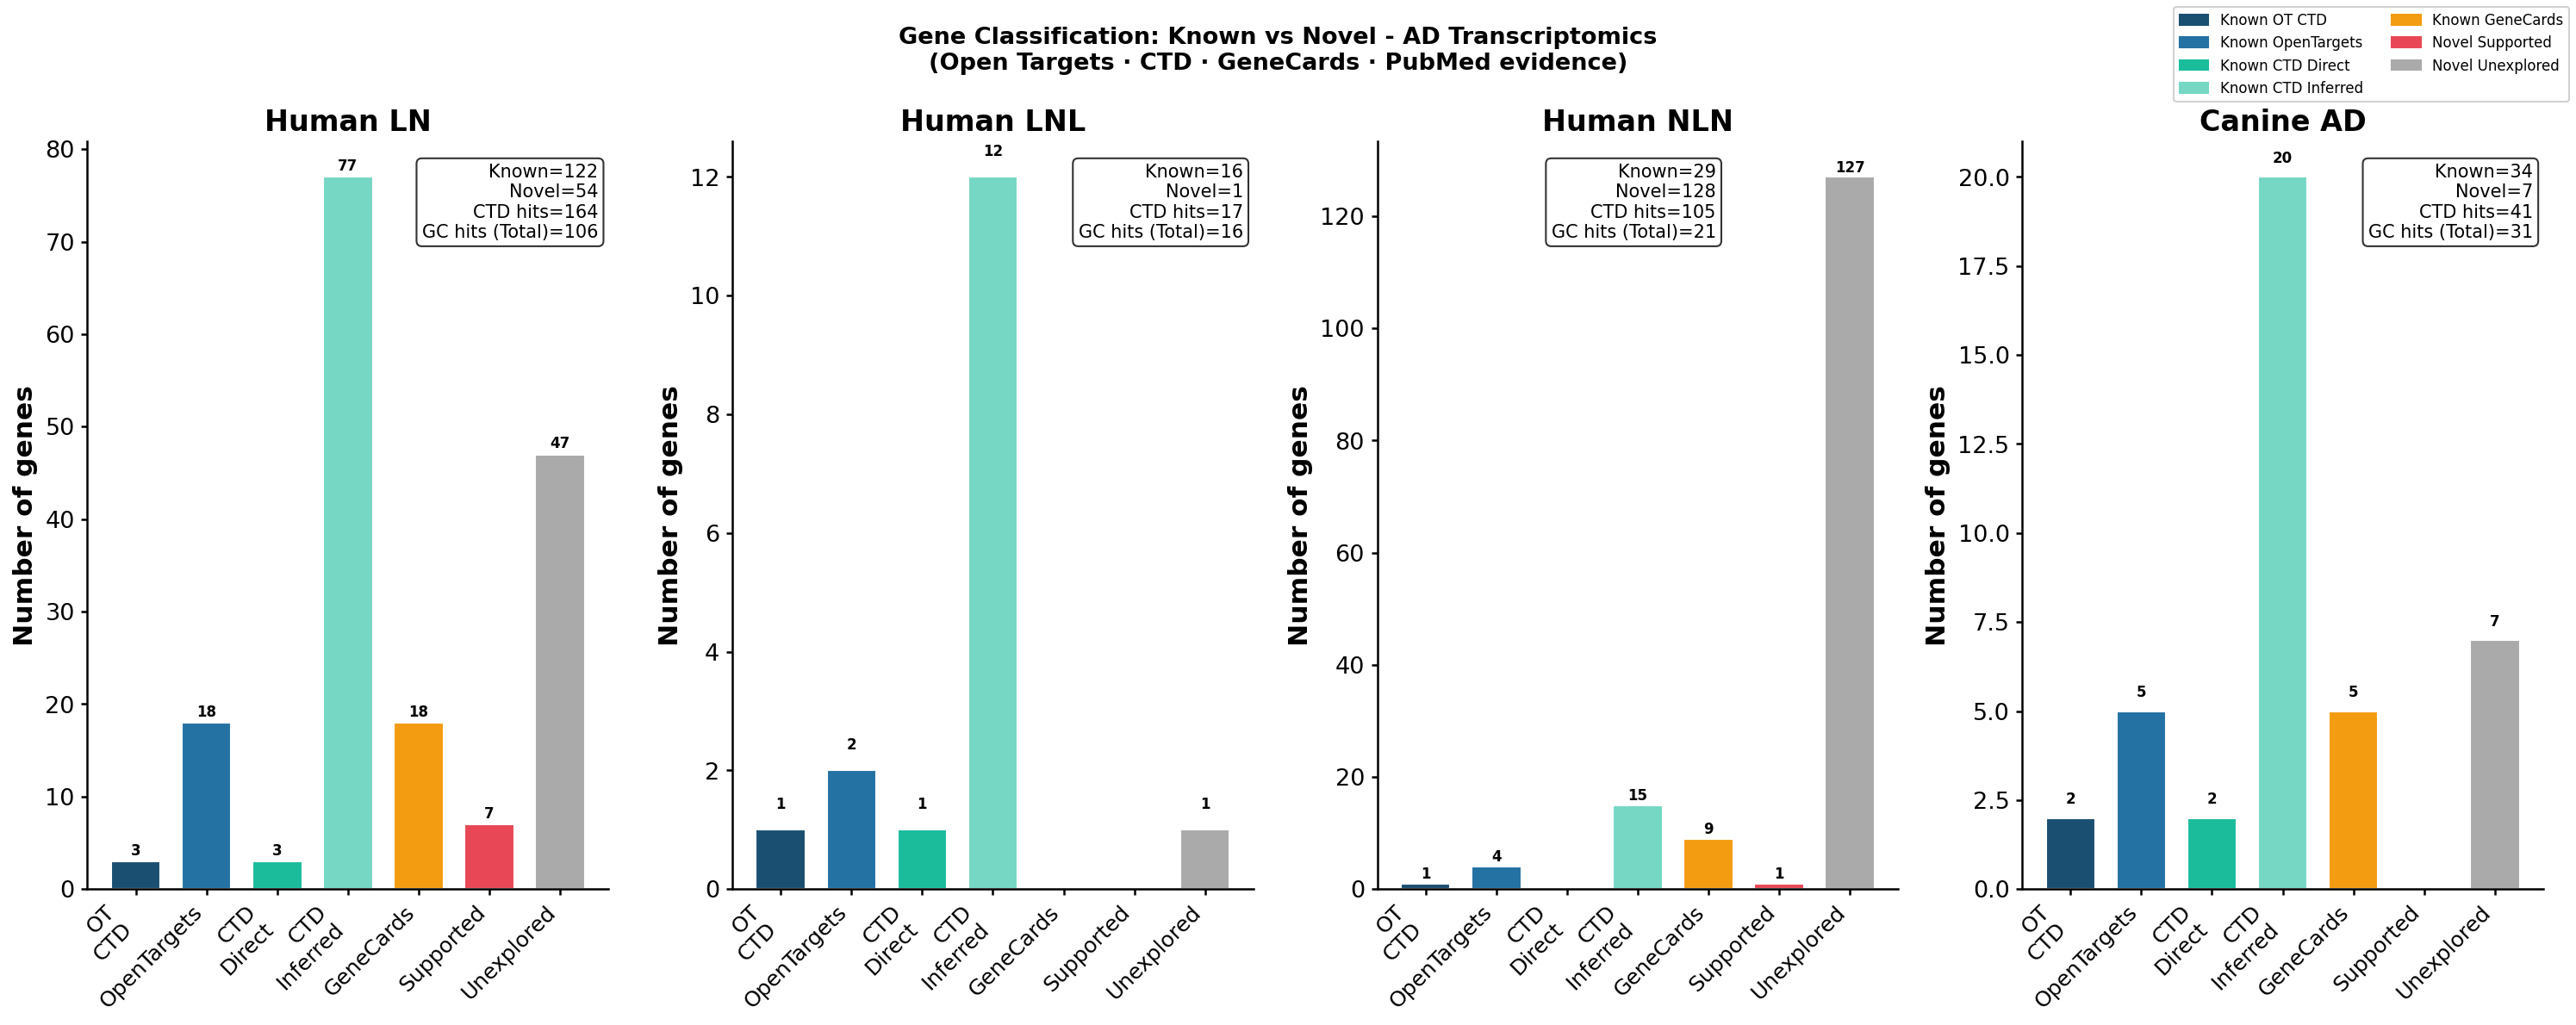

In [ ]:
import pandas as pd
import numpy as np
import os, json, time, re, requests, warnings
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
import seaborn as sns
import openpyxl
from openpyxl import Workbook
from openpyxl.styles import PatternFill, Font, Alignment
warnings.filterwarnings('ignore')

matplotlib.rcParams.update({
    'font.family'           : 'DejaVu Sans',
    'font.size'             : 14,
    'axes.labelsize'        : 15,
    'axes.titlesize'        : 16,
    'axes.titleweight'      : 'bold',
    'axes.labelweight'      : 'bold',
    'xtick.labelsize'       : 13,
    'ytick.labelsize'       : 13,
    'legend.fontsize'       : 12,
    'legend.title_fontsize' : 13,
    'axes.spines.top'       : False,
    'axes.spines.right'     : False,
    'axes.linewidth'        : 1.2,
    'xtick.major.width'     : 1.2,
    'ytick.major.width'     : 1.2,
    'figure.facecolor'      : 'white',
    'axes.facecolor'        : 'white',
    'savefig.dpi'           : 300,
    'figure.dpi'            : 150,
})
DPI = 300

BASE       = '/content/drive/MyDrive/Research/Atopic Dermatitis/Research Paper'
RES        = os.path.join(BASE, 'Results')
META       = os.path.join(RES,  'meta_summary')
IPA_DIR    = os.path.join(BASE, 'IPA')
INPUT_DATA = os.path.join(BASE, 'Input Data')

NB02       = os.path.join(RES,  'NB02')
NB02_FIG   = os.path.join(NB02, 'Figures')
NB02_TAB   = os.path.join(NB02, 'Tables')
NB02_SUP   = os.path.join(NB02, 'Supplementary_Files')
IPA_OUT    = os.path.join(NB02_TAB, 'IPA_Annotated')

NB01_TAB   = os.path.join(RES, 'NB01', 'Tables')

FIG_DIR    = NB02_FIG

for d in [NB02_FIG, NB02_TAB, NB02_SUP, IPA_OUT]:
    os.makedirs(d, exist_ok=True)

AD_EFO_ID             = 'EFO_0000274'
OPENTARGETS_THRESHOLD = 0.05
GENECARD_SCORE_MIN    = 1.0
PUBMED_THRESHOLD      = 1
NCBI_EMAIL            = 'sonalikaray97@gmail.com'

CLR = {'Known':'#2166AC','Novel_Supported':'#F4A261',
       'Novel_Unexplored':'#D62828','Up':'#D73027','Down':'#4575B4'}

# Reverted SUBCAT_COLORS to the single Known_CTD_Inferred category
SUBCAT_COLORS = {
    'Known_OT_CTD'       : '#1B4F72',
    'Known_OpenTargets'  : '#2471A3',
    'Known_CTD_Direct'   : '#1ABC9C',
    'Known_CTD_Inferred' : '#76D7C4', # Reverted to single color
    'Known_GeneCards'    : '#F39C12',
    'Known_PubMed'       : '#E67E22',
    'Novel_Supported'    : '#E84855',
    'Novel_Unexplored'   : '#AAAAAA',
}

def save_fig(fig, name):
    for ext in ['png', 'svg', 'pdf', 'jpeg']:
        path = os.path.join(FIG_DIR, f'{name}.{ext}')
        fig.savefig(path, dpi=DPI if ext in ['png', 'jpeg'] else None,
                    bbox_inches='tight', facecolor='white',
                    format=ext)
    print(f'  Saved: {name}.png / .svg / .pdf / .jpeg')
    plt.show()
    plt.close(fig)


# Figure 1 — Classification breakdown (all 6 databases)
# Reverted to single Known_CTD_Inferred category
cat_order = [
    'Known_OT_CTD',
    'Known_OpenTargets',
    'Known_CTD_Direct',
    'Known_CTD_Inferred', # Reverted to single category
    'Known_GeneCards',
    #'Known_PubMed', # Removed from plot order
    'Novel_Supported',
    'Novel_Unexplored',
]
cat_colors = SUBCAT_COLORS # Use the updated predefined granular colors

comp_data = [("Human LN",clf_LN),("Human LNL",clf_LNL),
             ("Human NLN",clf_NLN),("Canine AD",clf_canine)]

# Store PubMed-supported CTD_Inferred counts for each comparison
ctd_inferred_pubmed_counts = {
    "Human LN": 77,
    "Human LNL": 12,
    "Human NLN": 15,
    "Canine AD": 20
}

fig, axes = plt.subplots(1,4,figsize=(20,8)) # Adjusted figsize for fewer categories
for ax, (lbl, df) in zip(axes, comp_data):
    # Initialize value counts for all granular categories that will be plotted
    vc_dict = {k: 0 for k in cat_order}

    # Iterate through the DataFrame to assign counts to categories
    for _, row in df.iterrows():
        category = row["Category"]
        # Reverted to treating 'Known_CTD_Inferred' as a single category
        if category == 'Known_CTD_Inferred':
            vc_dict['Known_CTD_Inferred'] += 1
        elif category in vc_dict: # Ensure other categories are still counted if they are in cat_order
            vc_dict[category] += 1
        # Genes originally classified as 'Known_PubMed' are not added to vc_dict, effectively removing them from the plot.

    vc = pd.Series(vc_dict).reindex(cat_order, fill_value=0) # Ensure order and fill missing

    cats = vc.index.tolist()
    vals = vc.values.tolist()
    cols = [cat_colors[c] for c in cats]

    bars = ax.bar(range(len(cats)),vals,color=cols,edgecolor="white",width=0.7)
    for bar,val in zip(bars,vals):
        if val > 0: # Only show label for bars with count > 0
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                    str(val), ha="center", va="bottom", fontsize=8, fontweight="bold")
    ax.set_xticks(range(len(cats)))
    # Reverted xticklabels for better readability of categories
    xtick_labels = []
    for c in cats:
        if c == 'Known_CTD_Inferred':
            xtick_labels.append('CTD\nInferred')
        else:
            xtick_labels.append(c.replace("_","\n").replace("Known\n","").replace("Novel\n",""))
    ax.set_xticklabels(xtick_labels,fontsize=12,rotation=45,ha="right")
    ax.set_ylabel("Number of genes")
    ax.set_title(lbl,fontweight="bold")
    k = (df["Status"]=="Known").sum(); n = (df["Status"]=="Novel").sum()
    # Corrected: Summing 'In_CTD_Direct' and 'In_CTD_Inferred' for total CTD hits
    ctd_n = (df["In_CTD_Direct"] | df["In_CTD_Inferred"]).sum();
    gc_n = df["In_GeneCards"].sum()

    # Add CTD_Inferred_PubMed count to the text box
    ctd_inf_pm_count = ctd_inferred_pubmed_counts.get(lbl, 0)
    gc_known_category_count = vc_dict.get('Known_GeneCards', 0)

    x_text_pos = 0.98
    if lbl == "Human NLN": # Adjust for Human NLN subplot
        x_text_pos = 0.65

    ax.text(x_text_pos,0.97,f"Known={k}\nNovel={n}\nCTD hits={ctd_n}\nGC hits (Total)={gc_n}",
            transform=ax.transAxes, ha="right",va="top",fontsize=10,
            bbox=dict(boxstyle="round,pad=0.3",fc="white",alpha=0.8))

# Update patches for legend to reflect granular categories (excluding Known_PubMed)
legend_colors = {k: v for k, v in SUBCAT_COLORS.items() if k in cat_order}
patches = [mpatches.Patch(color=v,label=k.replace("_"," "))
           for k,v in legend_colors.items()]
fig.legend(handles=patches,loc="upper right",ncol=2,fontsize=8,
           framealpha=0.9)
fig.suptitle("Gene Classification: Known vs Novel - AD Transcriptomics\n"
             "(Open Targets \u00B7 CTD \u00B7 GeneCards \u00B7 PubMed evidence)",
             fontweight="bold",fontsize=13)
fig.tight_layout()
save_fig(fig,"NB3_Fig1_Classification_Breakdown")

In [ ]:
# Calculate and display counts for 'Known_CTD_Inferred' genes that also have PubMed evidence
print("Number of 'Known_CTD_Inferred' genes with PubMed evidence:")
for lbl, df in [('Human LN', clf_LN), ('Human LNL', clf_LNL),
                ('Human NLN', clf_NLN), ('Canine AD', clf_canine)]:
    if not df.empty and 'Category' in df.columns and 'PubMed_AD_hits' in df.columns:
        ctd_inferred_with_pubmed = df[
            (df['Category'] == 'Known_CTD_Inferred') &
            (df['PubMed_AD_hits'] >= 1)
        ]
        print(f"  {lbl}: {len(ctd_inferred_with_pubmed)} genes")
    else:
        print(f"  {lbl}: No data available or required columns missing.")

Number of 'Known_CTD_Inferred' genes with PubMed evidence:
  Human LN: 77 genes
  Human LNL: 12 genes
  Human NLN: 15 genes
  Canine AD: 20 genes


  Saved: NB3_Fig2_Top_Novel_Genes.png / .svg / .pdf / .jpeg


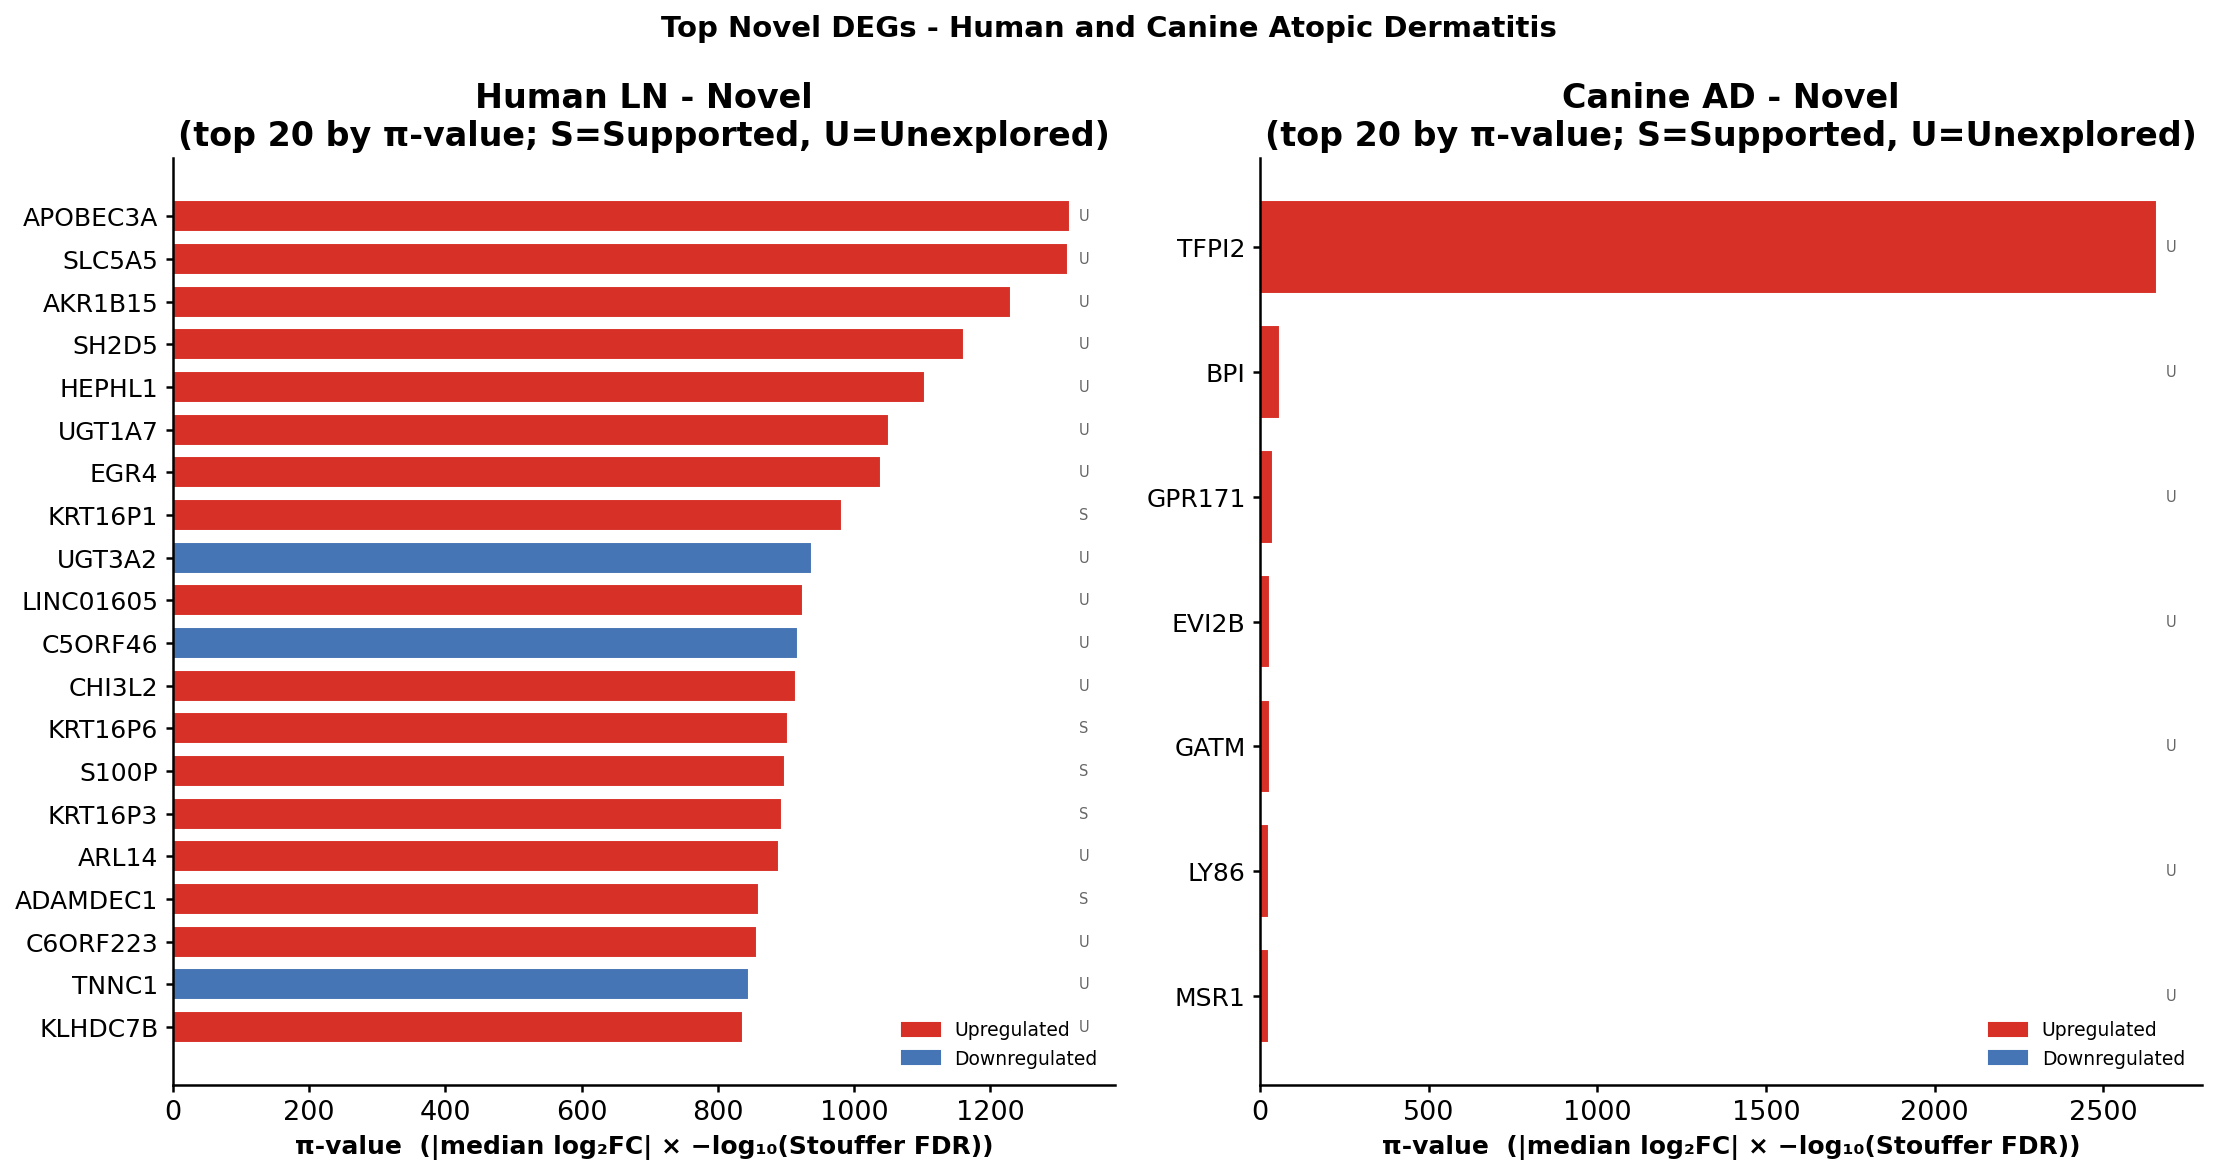

In [ ]:
# Figure 2 — Top Novel genes by pi-value (human LN + canine)
fig, axes = plt.subplots(1,2,figsize=(15,8))
for ax, (lbl, df, col) in zip(axes,[('Human LN - Novel',clf_LN,'#D6604D'),
                                      ('Canine AD - Novel',clf_canine,'#E58F1A')]):
    novel_df = df[df['Status']=='Novel'].copy()
    if 'pi_value' in novel_df.columns and not novel_df['pi_value'].isna().all():
        pi_col = 'pi_value'
    else:
        pi_col = None
    if pi_col:
        novel_df = novel_df.dropna(subset=[pi_col]).nlargest(20,pi_col)
        novel_df = novel_df.sort_values(pi_col,ascending=True)
    else:
        novel_df = novel_df.head(20)
    fc_col = next((c for c in novel_df.columns if 'log2fc' in c.lower() or 'log2_fc' in c.lower()),None)
    if fc_col:
        colors_ = ['#D73027' if v>0 else '#4575B4' for v in novel_df[fc_col]]
    else:
        colors_ = ['#D73027']*len(novel_df)
    bars = ax.barh(range(len(novel_df)),
                   novel_df[pi_col] if pi_col else range(len(novel_df)),
                   color=colors_,edgecolor='white',height=0.75)
    ax.set_yticks(range(len(novel_df)))
    ax.set_yticklabels(novel_df['Gene_Symbol'],fontsize=12)
    # Annotate category on right
    for i,(_,row) in enumerate(novel_df.iterrows()):
        c = 'S' if row.get('Category','')=='Novel_Supported' else 'U'
        ax.text((novel_df[pi_col].max() if pi_col else 20)*1.01,i,c,
                fontsize=7,va='center',color='#666')
    ax.set_xlabel('π-value  (|median log₂FC| × −log₁₀(Stouffer FDR))',fontsize=12)
    ax.set_title(f'{lbl}\n(top 20 by π-value; S=Supported, U=Unexplored)',fontweight='bold')
    patches_ = [mpatches.Patch(color='#D73027',label='Upregulated'),
                mpatches.Patch(color='#4575B4',label='Downregulated')]
    ax.legend(handles=patches_,frameon=False,fontsize=9,loc='lower right')

fig.suptitle('Top Novel DEGs - Human and Canine Atopic Dermatitis',
             fontweight='bold',fontsize=14)
fig.tight_layout()
save_fig(fig,'NB3_Fig2_Top_Novel_Genes')


## **Step 9 - Annotate IPA Tables**


In [ ]:
def extract_gene_set(cell_value):
    return {g.strip().upper() for g in str(cell_value).split(',')
            if g.strip() and len(g.strip())<30 and g.strip().upper() != 'NONE'}

def find_novel_in_cell(cell_value, novel_set):
    hits = sorted(extract_gene_set(cell_value) & novel_set)
    return ', '.join(hits) if hits else ''

def find_ipa_file(fname):
    for d in [IPA_DIR, os.path.join(BASE,'Input Data')]:
        p = os.path.join(d, fname)
        if os.path.exists(p): return p
    return None

IPA_FILES = {
    'Human' : ('All_IPA Result_Homo Sapiens.xlsx',  novel_human),
    'Canine': ('Dogs _ IPA and iLINCS result.xlsx', novel_canine),
}

annotated = {}
for species, (fname, novel_set) in IPA_FILES.items():
    path = find_ipa_file(fname)
    if not path:
        print(f'  ⚠ IPA file not found: {fname}'); continue
    wb = openpyxl.load_workbook(path, read_only=True, data_only=True)
    sheets_dict = {}
    print(f'  {species}: {fname} ({len(wb.sheetnames)} sheets)')
    for sname in wb.sheetnames:
        ws   = wb[sname]
        rows = list(ws.iter_rows(values_only=True))
        if not rows or len(rows)<2: continue
        max_c  = max(len(r) for r in rows[:5])
        header = [str(rows[0][i] or f'col_{i}').strip()[:60] if i<len(rows[0]) else f'col_{i}'
                  for i in range(max_c)]
        data   = [[r[i] if i<len(r) else None for i in range(max_c)]
                  for r in rows[1:] if any(v is not None for v in r)]
        if not data: continue
        df = pd.DataFrame(data, columns=header).astype(str).replace('None','')
        mol_cols = [c for c in df.columns
                    if any(k in c.lower() for k in ['molecule','target','genes','submitted'])]
        if not mol_cols:
            mol_cols = [c for c in df.columns
                        if df[c].dropna().head(5).apply(lambda v:',' in str(v) and len(str(v))>15).any()]
        if not mol_cols: mol_cols = [df.columns[-1]]
        df['Novel_Genes_in_Row'] = df[mol_cols[0]].apply(lambda v: find_novel_in_cell(v,novel_set))
        n_hit = (df['Novel_Genes_in_Row']!='').sum()
        sheets_dict[sname] = df
        print(f'    {sname:<35}: {len(df)} rows | {n_hit} rows with novel genes')
    annotated[species] = sheets_dict

# Save annotated Excel
NOVEL_CLR_FILL = PatternFill(start_color='FFC7CE',end_color='FFC7CE',fill_type='solid')
for species, sheets in annotated.items():
    if not sheets: continue
    out_path = os.path.join(IPA_OUT,f'IPA_{species}_Annotated.xlsx')
    wb_out   = Workbook(); wb_out.remove(wb_out.active)
    for sname, df in sheets.items():
        if df.empty: continue
        ws = wb_out.create_sheet(title=sname[:31])
        hf = PatternFill(start_color='1F4E79',end_color='1F4E79',fill_type='solid')
        hfnt= Font(color='FFFFFF',bold=True)
        for ci,col in enumerate(df.columns,1):
            c=ws.cell(row=1,column=ci,value=col); c.fill=hf; c.font=hfnt
        nci = list(df.columns).index('Novel_Genes_in_Row')+1 if 'Novel_Genes_in_Row' in df.columns else None
        for ri,row_data in enumerate(df.itertuples(index=False),2):
            for ci,val in enumerate(row_data,1):
                ws.cell(row=ri,column=ci,value=str(val) if val else '')
            if nci:
                v = str(ws.cell(row=ri,column=nci).value or '')
                if v: ws.cell(row=ri,column=nci).fill=NOVEL_CLR_FILL; ws.cell(row=ri,column=nci).font=Font(bold=True)
    wb_out.save(out_path)
    print(f'  ✓ IPA_{species}_Annotated.xlsx saved')


# ── Save IPA novel gene summary CSV (needed by NB6) ─────────────────────
ipa_summary_rows = []
ipa_detail_rows  = []
for species, sheets in annotated.items():
    clf_df = clf_LN if species=="Human" else clf_canine
    gene_set_ = set(clf_df[clf_df["Status"]=="Novel"]["Gene_Symbol"])
    for sname, df in sheets.items():
        if "Novel_Genes_in_Row" not in df.columns: continue
        for gene in gene_set_:
            n_hits = int(df["Novel_Genes_in_Row"].str.contains(
                r"\b" + re.escape(gene) + r"\b", na=False, regex=True).sum())
            if n_hits > 0:
                ipa_detail_rows.append({
                    "Gene": gene, "Species": species,
                    "IPA_Sheet": sname, "N_rows_hit": n_hits})

# Collapse to summary
if ipa_detail_rows:
    det_df = pd.DataFrame(ipa_detail_rows)
    det_df.to_csv(os.path.join(NB02_TAB,"IPA_novel_gene_hits_detailed.csv"), index=False)
    print("  Saved: IPA_novel_gene_hits_detailed.csv")
    summ = (det_df.groupby(["Gene","Species"])
                  .agg(N_Contexts=("IPA_Sheet","nunique"),
                       N_Rows=("N_rows_hit","sum"),
                       IPA_Sheets=("IPA_Sheet", lambda x: "; ".join(sorted(x.unique()))))
                  .reset_index())
    cat_lookup = {}
    for df_, sp in [(clf_LN,"Human"),(clf_canine,"Canine")]:
        for _,r in df_.iterrows():
            cat_lookup[(r["Gene_Symbol"],sp)] = r.get("Category","Novel")
    summ["Category"] = summ.apply(
        lambda r: cat_lookup.get((r["Gene"],r["Species"]),"Novel_Unexplored"), axis=1)
    summ.to_csv(os.path.join(NB02_TAB,"IPA_novel_gene_summary.csv"), index=False)
    print(f"  Saved: IPA_novel_gene_summary.csv ({len(summ)} unique genes)")
else:
    pd.DataFrame(columns=["Gene","Species","N_Contexts","N_Rows","IPA_Sheets","Category"])\
      .to_csv(os.path.join(NB02_TAB,"IPA_novel_gene_summary.csv"), index=False)
    pd.DataFrame(columns=["Gene","Species","IPA_Sheet","N_rows_hit"])\
      .to_csv(os.path.join(NB02_TAB,"IPA_novel_gene_hits_detailed.csv"), index=False)
    print("  IPA novel gene summaries: no IPA files found (empty placeholders saved)")


  Human: All_IPA Result_Homo Sapiens.xlsx (14 sheets)
    Literature                         : 442 rows | 0 rows with novel genes
    GS                                 : 21 rows | 0 rows with novel genes
    CP                                 : 1043 rows | 306 rows with novel genes
    MLD                                : 1480 rows | 250 rows with novel genes
    DB                                 : 1000 rows | 762 rows with novel genes
    Molecules                          : 1161 rows | 0 rows with novel genes
    UR                                 : 5950 rows | 0 rows with novel genes
    TF                                 : 734 rows | 131 rows with novel genes
    Networks                           : 25 rows | 21 rows with novel genes
    Comp_CP                            : 227 rows | 0 rows with novel genes
    Lit_Comp_CP                        : 145 rows | 0 rows with novel genes
    Comp DB                            : 582 rows | 0 rows with novel genes
    Lit_Comp_DB       

## **Step 9b — Add Pathway Category to Combined IPA File**

Reads `IPA_All_Species_Annotated.xlsx` from `NB02/Supplementary_Files/`, adds a
`Pathway_Category` column to `Human_CP` and `Canin_CP` sheets, and saves
`IPA_All_Species_Annotated_v2.xlsx` to the same folder.

**Three tiers** are encoded in each category label:
- `(AD-core)` — directly AD-relevant → use in main figures
- `(Skin-adjacent)` — skin/barrier biology → include with annotation
- `(Off-target)` — not primarily AD → supplementary only


In [45]:
# ── Pathway category rules ────────────────────────────────────────────────────
# Each rule: (regex_pattern, category_label)
# First match wins. Tier is embedded in label: (AD-core) | (Skin-adjacent) | (Off-target)

PATHWAY_RULES = [
    # ── AD-core: Adaptive Immune ──────────────────────────────────────────────
    (r'Th[12]\b|T\s*Helper|T\s*Cell\s*Receptor|CD28|CTLA[24]|PD-1|TCR\b|CD8\b',
     'Adaptive Immune (AD-core)'),

    # ── AD-core: IL cytokine signalling ───────────────────────────────────────
    (r'Interleukin.?(4|5|10|13|31|33)|IL-?(4|5|10|13|17|31|33)\b'
     r'|Cytokine\s*Storm|Hypercytokine'
     r'|Differential Regulation of Cytokine'
     r'|Interleukin-3.*GM-CSF|GM-CSF',
     'Cytokine Signalling (AD-core)'),

    # ── AD-core: Neutrophil / degranulation ───────────────────────────────────
    (r'Neutrophil|Degranulat|Extracellular Trap|NET\b',
     'Neutrophil / Degranulation (AD-core)'),

    # ── AD-core: Innate immune — pattern recognition / macrophage ─────────────
    (r'Macrophage|Toll.like|TLR\b|Pattern Recognition|MyD88|IRAK\b'
     r'|CGAS.STING|STING\b|TREM[12]\b|Complement\b',
     'Innate Immune / Pattern Recognition (AD-core)'),

    # ── AD-core: Skin / epidermal barrier ─────────────────────────────────────
    (r'Skin\b|Epidermal|Keratinocyte|Cornif|Barrier|Tight Junction'
     r'|Filaggrin|Loricrin|Desmosome',
     'Skin Barrier / Epidermal (AD-core)'),

    # ── Skin-adjacent: Zinc / fatty acid / DHA ────────────────────────────────
    # Zinc deficiency documented in AD; DHA/fatty acids underlie barrier lipids
    (r'Zinc|Zn\s*Homeostasis|Docosahexaenoic|DHA\b|Fatty Acid|Lipid\b|Eicosanoid',
     'Lipid / Zinc Metabolism (Skin-adjacent)'),

    # ── Skin-adjacent: Ion & amino acid transport ─────────────────────────────
    # Skin hydration, barrier ion gradient, SLC transporters
    (r'Transport.*[Ii]on|[Ii]on.*[Tt]ransport|[Aa]mino [Aa]cid.*[Tt]ransport'
     r'|[Tt]ransport of [Ii]on|Aquaporin',
     'Ion / Amino Acid Transport (Skin-adjacent)'),

    # ── Skin-adjacent: GPCR (itch / mast cell / keratinocyte) ────────────────
    (r'G.?Protein.?Coupled|GPCR|Adenylyl Cyclase|cAMP\b|Beta.Adrenerg',
     'GPCR Signalling (Skin-adjacent)'),

    # ── Skin-adjacent: Cell adhesion / ECM / FAK ─────────────────────────────
    (r'FAK\b|Integrin\b|Extracellular Matrix|ECM\b|Fibrosis|Hepatic Fibrosis'
     r'|Collagen\b|Adhesion\b',
     'Cell Adhesion / ECM (Skin-adjacent)'),

    # ── Skin-adjacent: Shared inflammatory mediators ──────────────────────────
    # Atherosclerosis / Glycation share IL-6, CCL2, S100 with AD — not AD-specific
    (r'Atherosclerosis|Glycation',
     'Shared Inflammatory Mediators (Skin-adjacent)'),

    # ── Skin-adjacent: Oxidative stress ──────────────────────────────────────
    (r'Reactive Oxygen|ROS\b|NADPH Oxidase|Free Radical|Oxidative',
     'Oxidative Stress (Skin-adjacent)'),

    # ── Cross-disease inflammatory ────────────────────────────────────────────
    (r'Multiple Sclerosis|Rheumatoid|Psoriasis|Crohn|Inflammatory Bowel|Colitis',
     'Inflammatory Disease (Cross-disease)'),

    # ── Off-target: MAPK / RAS / proliferation ────────────────────────────────
    (r'RAS\b|NF1\b|MAPK\b|ERK\b|MEK\b|mTOR\b|PI3K\b|Stathmin|ErbB\b|EGFR\b',
     'MAPK / Proliferation (Off-target)'),

    # ── Off-target: Developmental / WNT ──────────────────────────────────────
    (r'WNT\b|Wnt\b|Beta.catenin|Hedgehog|Notch\b',
     'Developmental Signalling (Off-target)'),

    # ── Off-target: Neurological ──────────────────────────────────────────────
    (r'Glutaminer|GABA\b|Dopamin|Serotonin|Synapt|BBSome|Cyclophilin'
     r'|Neurol|Parkinson|Alzheimer',
     'Neurological (Off-target)'),

    # ── Off-target: Coagulation ───────────────────────────────────────────────
    (r'Coagulat|Fibrin\b|Clot\b|Thrombos|Platelet',
     'Coagulation (Off-target)'),

    # ── Off-target: Cardiovascular ────────────────────────────────────────────
    (r'Cardiac|Cardiomyopathy|Hypertension|Aortic|Coronary',
     'Cardiovascular (Off-target)'),

    # ── Off-target: Cancer (non-skin) ─────────────────────────────────────────
    (r'Breast Cancer|Pancreatic|Glioma|Leukemia|Lymphoma|Colorectal'
     r'|Prostate|Ovarian|Lung Cancer|Bladder|Hepatocellular',
     'Cancer – Non-skin (Off-target)'),

    # ── Adjacent — skin cancer shares keratinocyte biology ───────────────────
    (r'Skin Cancer|Squamous Cell|Basal Cell|Melanocyte|Melanoma',
     'Skin Cancer (Adjacent)'),

    # ── Off-target: Metabolic / endocrine ────────────────────────────────────
    (r'Insulin\b|Glucos|Glyco|Hepatic\b|Liver\b|Thyroid|Steroid|Hormone\b'
     r'|Endocrin|Metabol',
     'Metabolic / Endocrine (Off-target)'),

    # ── Off-target: Apoptosis / DNA damage ───────────────────────────────────
    (r'Apoptosis|Autophagy|p53\b|DNA Damage|DNA Repair|ATM\b',
     'Apoptosis / DNA Damage (Off-target)'),
]

def categorise_pathway(name: str) -> str:
    """Return tier-labelled category for an IPA canonical pathway name."""
    if not isinstance(name, str):
        return 'Other'
    for pattern, label in PATHWAY_RULES:
        if re.search(pattern, name, re.IGNORECASE):
            return label
    return 'Other'


# ── Read combined IPA file, add Pathway_Category, save v2 ────────────────────
ipa_in_path  = os.path.join(NB02_SUP, 'IPA_All_Species_Annotated.xlsx')
ipa_out_path = os.path.join(NB02_SUP, 'IPA_All_Species_Annotated_v2.xlsx')

if not os.path.exists(ipa_in_path):
    print(f'  ⚠ File not found: {ipa_in_path}')
    print('  Make sure IPA_All_Species_Annotated.xlsx is in NB02/Supplementary_Files/')
else:
    ipa_xl    = pd.ExcelFile(ipa_in_path)
    # Updated to include DB, MLD, and TF sheets, explicitly adding 'ML Disease Pathways'
    pathway_sheets = [s for s in ipa_xl.sheet_names if any(suffix in s for suffix in ['_CP', '_DB', '_MLD', '_TF']) or s == 'ML Disease Pathways']

    with pd.ExcelWriter(ipa_out_path, engine='openpyxl') as writer:
        for sheet in ipa_xl.sheet_names:
            df = ipa_xl.parse(sheet)
            if sheet in pathway_sheets:
                pathway_col = df.columns[0]   # always the pathway name
                # Drop 'Pathway_Category' if it already exists to avoid ValueError
                if 'Pathway_Category' in df.columns:
                    df = df.drop(columns=['Pathway_Category'])
                df.insert(1, 'Pathway_Category',
                          df[pathway_col].apply(categorise_pathway))
            df.to_excel(writer, sheet_name=sheet, index=False)

    print(f'  ✓ Saved: IPA_All_Species_Annotated_v2.xlsx')
    print(f'  Pathway_Category column added to: {pathway_sheets}\n')

    # ── Category distribution summary ─────────────────────────────────────────
    ipa_v2 = pd.ExcelFile(ipa_out_path)
    for sheet in pathway_sheets: # Iterate through the expanded list of pathway sheets
        df = ipa_v2.parse(sheet)
        print(f'── {sheet} ({len(df)} pathways total) ──')
        vc = df['Pathway_Category'].value_counts()
        for cat, cnt in vc.items():
            tier_tag = ''
            if 'AD-core'        in cat: tier_tag = '  ◀ AD-relevant'
            elif 'Skin-adjacent' in cat: tier_tag = '  ◀ Skin-adjacent'
            elif 'Cross-disease' in cat: tier_tag = '  ◀ Cross-disease'
            print(f'  {cnt:>3}  {cat}{tier_tag}')
        print()

  ✓ Saved: IPA_All_Species_Annotated_v2.xlsx
  Pathway_Category column added to: ['Human_CP', 'Human_MLD', 'Human_DB', 'Human_TF', 'Human_Comp_CP', 'Human_Comp_DB', 'Human_Comp_TF', 'Canin_CP', 'Canin_DB', 'Canin_TF']

── Human_CP (197 pathways total) ──
  118  Other
   10  Cell Adhesion / ECM (Skin-adjacent)  ◀ Skin-adjacent
   10  Innate Immune / Pattern Recognition (AD-core)  ◀ AD-relevant
    9  Cytokine Signalling (AD-core)  ◀ AD-relevant
    7  Neurological (Off-target)
    6  Inflammatory Disease (Cross-disease)  ◀ Cross-disease
    6  MAPK / Proliferation (Off-target)
    5  Cancer – Non-skin (Off-target)
    5  Lipid / Zinc Metabolism (Skin-adjacent)  ◀ Skin-adjacent
    4  Adaptive Immune (AD-core)  ◀ AD-relevant
    4  Ion / Amino Acid Transport (Skin-adjacent)  ◀ Skin-adjacent
    3  Neutrophil / Degranulation (AD-core)  ◀ AD-relevant
    2  Metabolic / Endocrine (Off-target)
    2  Cardiovascular (Off-target)
    2  Shared Inflammatory Mediators (Skin-adjacent)  ◀ Skin-adj

In [47]:
# ── Categorize and summarise 'ML Disease Pathways' for Canine ─────────────────
# This sheet was processed from the original canine IPA file in Step 9
# and stored in the 'annotated' dictionary.

if 'Canine' in annotated and 'ML Disease Pathways' in annotated['Canine']:
    canine_mld_df = annotated['Canine']['ML Disease Pathways'].copy()

    # Ensure the 'Ingenuity Canonical Pathways' column (or similar) is used for categorization
    # Assuming the first column contains the pathway names based on previous logic
    pathway_col = canine_mld_df.columns[0]

    # Add Pathway_Category if it doesn't exist or re-categorize
    if 'Pathway_Category' in canine_mld_df.columns:
        canine_mld_df = canine_mld_df.drop(columns=['Pathway_Category'])

    canine_mld_df.insert(1, 'Pathway_Category',
                         canine_mld_df[pathway_col].apply(categorise_pathway))

    print(f'── ML Disease Pathways (Canine) ({len(canine_mld_df)} pathways total) ──')
    vc = canine_mld_df['Pathway_Category'].value_counts()
    for cat, cnt in vc.items():
        tier_tag = ''
        if 'AD-core'        in cat: tier_tag = '  ◀ AD-relevant'
        elif 'Skin-adjacent' in cat: tier_tag = '  ◀ Skin-adjacent'
        elif 'Cross-disease' in cat: tier_tag = '  ◀ Cross-disease'
        print(f'  {cnt:>3}  {cat}{tier_tag}')
    print()

    # Save the pathway category distribution to a CSV file
    output_path = os.path.join(NB02_TAB, 'canine_MLD_Pathway_Category_Distribution.csv')
    vc.to_csv(output_path, header=['Count'])
    print(f'  ✓ Saved: canine_MLD_Pathway_Category_Distribution.csv to {NB02_TAB}')

else:
    print("  'ML Disease Pathways' for Canine not found in 'annotated' dictionary.")
    print("  Please ensure the sheet was loaded correctly in Step 9.")

── ML Disease Pathways (Canine) (961 pathways total) ──
  763  Other
   68  Cancer – Non-skin (Off-target)
   40  Metabolic / Endocrine (Off-target)
   28  Cardiovascular (Off-target)
   17  Skin Cancer (Adjacent)
   11  Cell Adhesion / ECM (Skin-adjacent)  ◀ Skin-adjacent
   10  Skin Barrier / Epidermal (AD-core)  ◀ AD-relevant
    9  Inflammatory Disease (Cross-disease)  ◀ Cross-disease
    6  Coagulation (Off-target)
    3  Neurological (Off-target)
    2  Shared Inflammatory Mediators (Skin-adjacent)  ◀ Skin-adjacent
    2  Lipid / Zinc Metabolism (Skin-adjacent)  ◀ Skin-adjacent
    1  Innate Immune / Pattern Recognition (AD-core)  ◀ AD-relevant
    1  Oxidative Stress (Skin-adjacent)  ◀ Skin-adjacent

  ✓ Saved: canine_MLD_Pathway_Category_Distribution.csv to /content/drive/MyDrive/Research/Atopic Dermatitis/Research Paper/Results/NB02/Tables


In [50]:
if 'Canine' in annotated and 'ML Disease Pathways' in annotated['Canine']:
    canine_mld_df_processed = annotated['Canine']['ML Disease Pathways'].copy()

    # Recategorize to ensure Pathway_Category is up-to-date
    pathway_col = canine_mld_df_processed.columns[0] # Assuming first column has pathway names
    if 'Pathway_Category' in canine_mld_df_processed.columns:
        canine_mld_df_processed = canine_mld_df_processed.drop(columns=['Pathway_Category'])
    canine_mld_df_processed.insert(1, 'Pathway_Category',
                                 canine_mld_df_processed[pathway_col].apply(categorise_pathway))

    # Save the DataFrame to a text file
    output_txt_path = os.path.join(NB02_TAB, 'Canin_MLD_Pathway_Annotated.txt')
    canine_mld_df_processed.to_csv(output_txt_path, sep='\t', index=False)
    print(f"DataFrame saved to: {output_txt_path}")

    # Display the requested columns
    display(canine_mld_df_processed)
else:
    print("'ML Disease Pathways' for Canine not found in 'annotated' dictionary. Please ensure it was loaded and processed correctly.")

DataFrame saved to: /content/drive/MyDrive/Research/Atopic Dermatitis/Research Paper/Results/NB02/Tables/Canin_MLD_Pathway_Annotated.txt


,My Pathways,Pathway_Category,-log(p-value),Ratio,Molecules,col_4,col_5,col_6,col_7,col_8,...,col_17,col_18,col_19,col_20,col_21,col_22,col_23,col_24,col_25,Novel_Genes_in_Row
0,Hypersensitive reaction,Other,8.04,0.2,"CD300C,CD48,CD86,CSF2,FCER1A,IL13,IL33,IL9",,,,,,...,,,,,,,,,,
1,Immediate hypersensitivity,Other,5.99,0.188,"CD300C,CSF2,FCER1A,IL13,IL33,IL9",,,,,,...,,,,,,,,,,
2,Atopy,Other,5.99,0.188,"CD300C,CSF2,FCER1A,IL13,IL33,IL9",,,,,,...,,,,,,,,,,
3,Immune mediated inflammatory disease,Other,5.03,0.13,"ADA2,CSF2,IL13,IL33,IL6,IL9",,,,,,...,,,,,,,,,,
4,Hyperalgesia,Other,4.35,0.135,"C5AR1,CCL5,CSF2,IL33,IL6",,,,,,...,,,,,,,,,,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
956,Intrathoracic organ tumor,Other,1.22,0.0541,"EGFR,IL6",,,,,,...,,,,,,,,,,
957,Intraabdominal organ tumor,Other,1.22,0.0541,"CSF2,IL6",,,,,,...,,,,,,,,,,
958,Non-squamous lung cancer,Cancer – Non-skin (Off-target),0.38,0.02,EGFR,,,,,,...,,,,,,,,,,
959,Formation of solid tumor,Other,0.439,0.0238,EGFR,,,,,,...,,,,,,,,,,


## **Figure 3 — IPA Canonical Pathways Dot-plot (AD-Relevant)**

Dot-plot showing significant IPA canonical pathways filtered to AD-relevant tiers only.

- **X-axis**: −log₁₀(p-value) — statistical significance
- **Y-axis**: Pathway name (bold = AD-core tier)
- **Dot size**: Number of novel genes in that pathway
- **Dot colour**: Activation z-score (red = activated, blue = inhibited)
- **Dashed line**: p = 0.05 threshold (−log₁₀ p = 1.3)

Saved as `Figure3_IPA_Pathway_Dotplot.png` + `.svg` + `.pdf` at 300 DPI.


AD-relevant human pathways : 55
AD-relevant canine pathways: 34

Human — novel genes per pathway:
  [Skin-adjacent] Ion channel transport | z=3.05 | novel: ATP6V0D2, CASQ1
  [Skin-adjacent] Transport of inorganic cations/anions and amino acids/olig | z=3.00 | novel: SLC26A6, SLC38A5, SLC4A5, SLC5A5
  [Skin-adjacent] Transport of bile salts and organic acids, metal ions and  | z=2.83 | novel: RHCG, SLC22A16, SLC30A2
  [Skin-adjacent] Docosahexaenoic Acid (DHA) Signaling | z=3.00 | novel: FABP9
  [Skin-adjacent] FAK Signaling | z=5.59 | novel: FSHR, NPY5R
  [Skin-adjacent] Hepatic Fibrosis Signaling Pathway | z=4.04 | novel: RND1
  [Skin-adjacent] G-Protein Coupled Receptor Signaling | z=3.96 | novel: FSHR, GNAT2, GNAZ, GPRIN1, NPY5R
  [Skin-adjacent] Zn Homeostasis Signaling Pathway | z=3.06 | novel: BMP3, BMP8B, FSHR, NPY5R, SLC30A2
  [Cross-disease] Role of Osteoclasts in Rheumatoid Arthritis Signaling Path | z=3.90 | novel: RND1
  [Cross-disease] Role of Osteoblasts in Rheumatoid Art

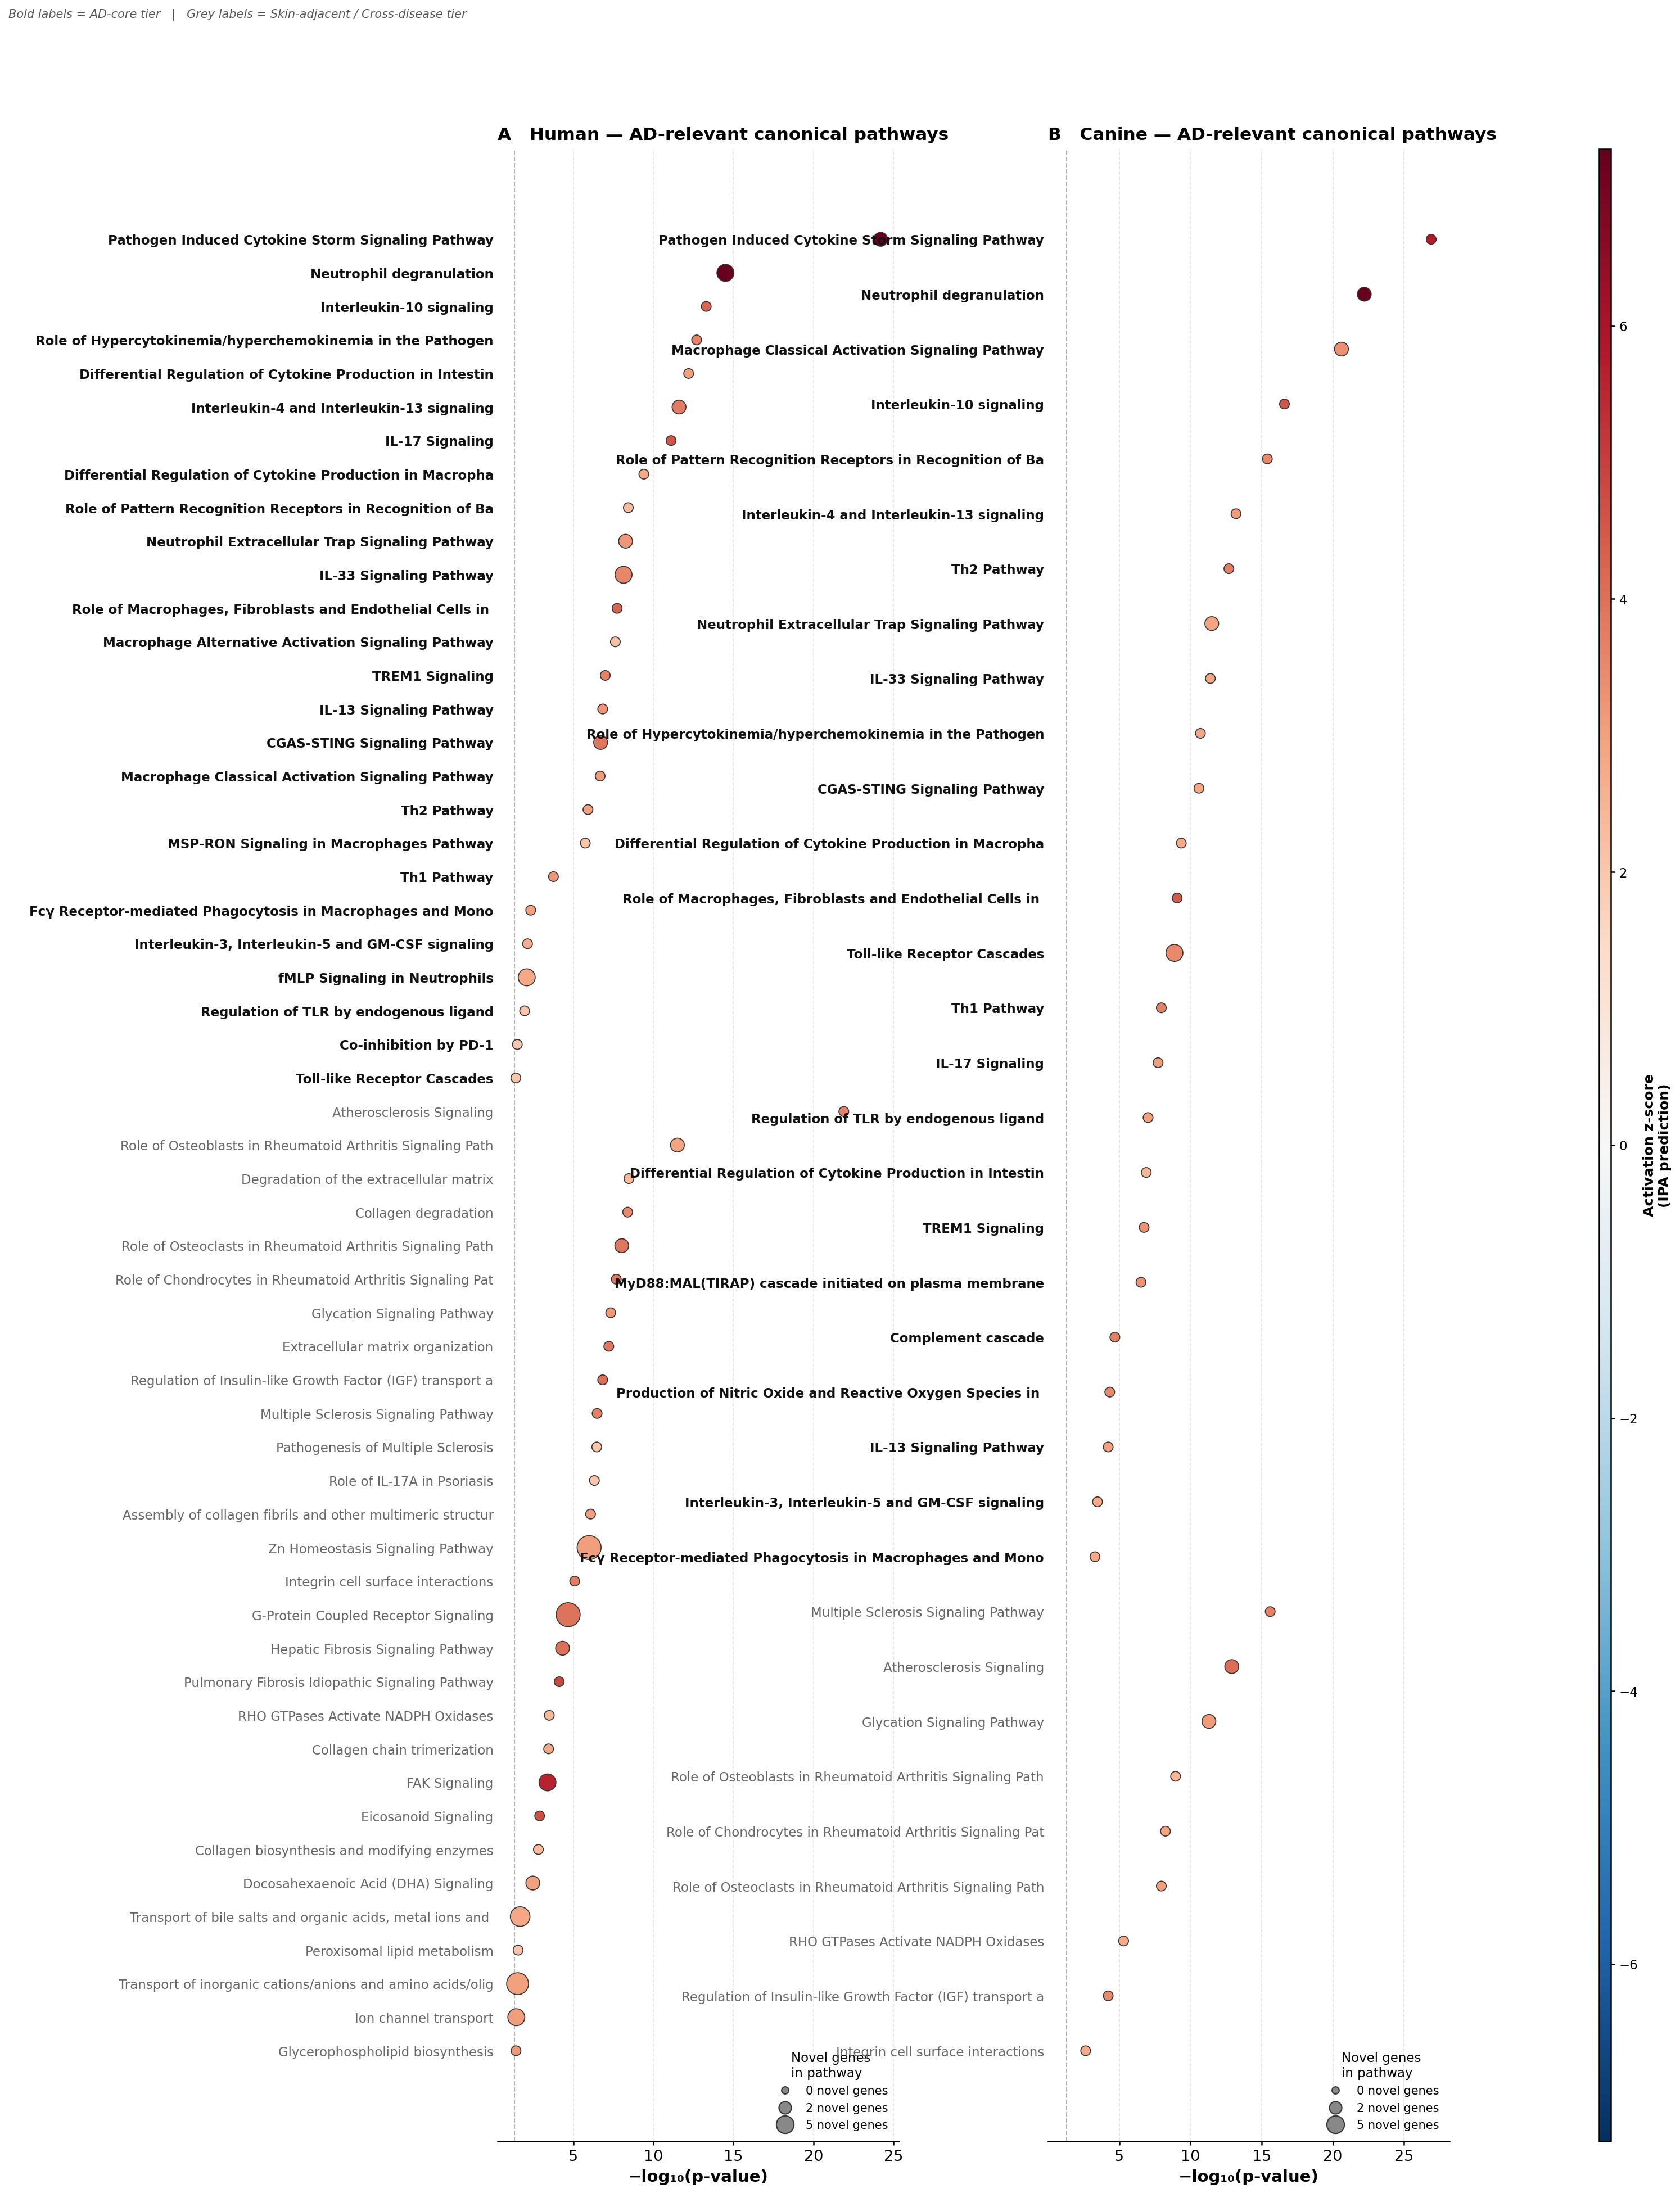

In [ ]:
# ── AD-relevant tier list ─────────────────────────────────────────────────────
AD_TIERS = [
    'Adaptive Immune (AD-core)',
    'Cytokine Signalling (AD-core)',
    'Neutrophil / Degranulation (AD-core)',
    'Innate Immune / Pattern Recognition (AD-core)',
    'Skin Barrier / Epidermal (AD-core)',
    'Lipid / Zinc Metabolism (Skin-adjacent)',
    'Ion / Amino Acid Transport (Skin-adjacent)',
    'GPCR Signalling (Skin-adjacent)',
    'Cell Adhesion / ECM (Skin-adjacent)',
    'Shared Inflammatory Mediators (Skin-adjacent)',
    'Oxidative Stress (Skin-adjacent)',
    'Inflammatory Disease (Cross-disease)',
]

# ── Load v2 IPA file ──────────────────────────────────────────────────────────
if not os.path.exists(ipa_out_path):
    print('Run Step 9b first to generate IPA_All_Species_Annotated_v2.xlsx')
else:
    ipa_v2 = pd.ExcelFile(ipa_out_path)

    def prep_cp(sheet_name, min_logp=1.3):
        """Load a CP sheet, apply significance + AD-tier filter, compute helpers."""
        df = ipa_v2.parse(sheet_name).copy()
        df = df[df['-log(p-value)'] >= min_logp]
        df = df[df['Pathway_Category'].isin(AD_TIERS)].copy()
        df['n_novel'] = df['Novel_Genes_in_Row'].apply(
            lambda x: len(str(x).split(','))
            if pd.notna(x) and str(x).strip() not in ('', 'nan') else 0)
        df['z_score'] = pd.to_numeric(df['z-score'], errors='coerce')
        df['logp']    = df['-log(p-value)']
        df['label']   = df['Ingenuity Canonical Pathways'].str[:58]
        # AD-core rows sorted above Skin-adjacent within same logp
        df['is_core'] = df['Pathway_Category'].str.contains('AD-core').astype(int)
        df = df.sort_values(['is_core', 'logp'], ascending=[True, True])
        return df.reset_index(drop=True)

    human_cp = prep_cp('Human_CP')
    canin_cp = prep_cp('Canin_CP')

    print(f'AD-relevant human pathways : {len(human_cp)}')
    print(f'AD-relevant canine pathways: {len(canin_cp)}')
    if len(human_cp) > 0:
        print('\nHuman — novel genes per pathway:')
        for _, r in human_cp[human_cp['n_novel'] > 0].iterrows():
            print(f'  [{r["Pathway_Category"].split("(")[1][:-1]}] '
                  f'{r["label"]} | z={r["z_score"]:.2f} | novel: {r["Novel_Genes_in_Row"]}')

    # ── Drawing function ──────────────────────────────────────────────────────
    def draw_cp_dotplot(ax, df, title='', cbar_ax=None):
        if df.empty:
            ax.text(0.5, 0.5, 'No pathways pass filter',
                    transform=ax.transAxes, ha='center', va='center', fontsize=13)
            ax.set_title(title, fontsize=16, fontweight='bold', loc='left')
            return None

        y      = np.arange(len(df))
        z_vals = df['z_score'].fillna(0)
        vmax   = max(abs(z_vals).max(), 2.5)
        norm   = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
        cmap   = matplotlib.colormaps['RdBu_r']
        sizes  = (df['n_novel'].clip(0, 8) + 1) * 70

        sc = ax.scatter(df['logp'], y, c=z_vals, cmap=cmap, norm=norm,
                        s=sizes, edgecolors='#333333', linewidths=0.8, zorder=3)

        ax.set_yticks(y)
        yticklabels = ax.set_yticklabels(df['label'], fontsize=11)
        # Bold + dark = AD-core; normal + grey = Skin-adjacent
        for tick, is_core in zip(yticklabels, df['is_core']):
            tick.set_fontweight('bold'   if is_core else 'normal')
            tick.set_color('#111111'     if is_core else '#666666')

        ax.set_xlabel('−log₁₀(p-value)', fontsize=14, fontweight='bold')
        ax.set_title(title, fontsize=15, fontweight='bold', loc='left', pad=8)
        ax.axvline(1.3, color='grey', lw=1.0, ls='--', alpha=0.6)
        ax.xaxis.grid(True, ls='--', alpha=0.35, zorder=0)
        ax.set_axisbelow(True)
        ax.spines['left'].set_visible(False)
        ax.tick_params(axis='y', length=0)

        if cbar_ax is not None:
            cb = plt.colorbar(sc, cax=cbar_ax)
            cb.set_label('Activation z-score\n(IPA prediction)', fontsize=12)
            cb.ax.tick_params(labelsize=11)
        return sc

    def add_size_legend(ax, novel_counts=(0, 2, 5)):
        handles = [
            Line2D([0], [0], marker='o', color='w',
                   markerfacecolor='#888888', markeredgecolor='#333333',
                   markersize=np.sqrt((n + 1) * 70 / np.pi) * 1.3,
                   label=f'{n} novel gene{"s" if n != 1 else ""}')
            for n in novel_counts
        ]
        ax.legend(handles=handles, title='Novel genes\nin pathway',
                  frameon=False, fontsize=10, title_fontsize=11,
                  loc='lower right')

    # ── Build figure ──────────────────────────────────────────────────────────
    n_h   = max(len(human_cp), 1)
    n_c   = max(len(canin_cp), 1)
    fig_h = max(n_h, n_c) * 0.46 + 2.5

    fig = plt.figure(figsize=(20, max(fig_h, 7)))
    gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.55,
                            width_ratios=[1, 1, 0.03],
                            left=0.30, right=0.96, top=0.93, bottom=0.08)
    ax_H    = fig.add_subplot(gs[0])
    ax_C    = fig.add_subplot(gs[1])
    cbar_ax = fig.add_subplot(gs[2])

    draw_cp_dotplot(ax_H, human_cp,
                    title='A   Human — AD-relevant canonical pathways',
                    cbar_ax=cbar_ax)
    draw_cp_dotplot(ax_C, canin_cp,
                    title='B   Canine — AD-relevant canonical pathways')

    add_size_legend(ax_H)
    add_size_legend(ax_C)

    fig.text(0.01, 0.99,
             'Bold labels = AD-core tier   |   Grey labels = Skin-adjacent / Cross-disease tier',
             fontsize=10, color='#555555', style='italic', va='top')

    save_fig(fig, 'Figure3_IPA_Pathway_Dotplot')


In [ ]:
import shutil

print('='*65)
print('NB02 CLASSIFICATION COMPLETE')
print('='*65)
for lbl,df in [('Human LN',clf_LN),('Human LNL',clf_LNL),
               ('Human NLN',clf_NLN),('Canine AD',clf_canine)]:
    k=(df['Status']=='Known').sum(); n=(df['Status']=='Novel').sum()
    ot_n=df['In_OpenTargets'].sum();
    # Corrected: Use In_CTD_Direct or In_CTD_Inferred to count CTD hits
    ctd_n=(df['In_CTD_Direct'] | df['In_CTD_Inferred']).sum()
    gc_n=df['In_GeneCards'].sum();   pm_n=df['In_PubMed'].sum()
    print(f'  {lbl:<15}: Known={k} (OT={ot_n},CTD={ctd_n},GC={gc_n},PM={pm_n}) | Novel={n}')

# Consolidated classification Excel
supp3_path = os.path.join(NB02_SUP, 'Supplementary_File_3_Classification_Tables.xlsx')
cat_order  = ['Known_OT_CTD','Known_OpenTargets','Known_CTD','Known_GeneCards',
              'Known_PubMed','Novel_Supported','Novel_Unexplored']
with pd.ExcelWriter(supp3_path, engine='openpyxl') as writer:
    for sname, df in [('Human_LN', clf_LN), ('Human_LNL', clf_LNL),
                      ('Human_NLN', clf_NLN), ('Canine_AD', clf_canine)]:
        out_cols = ['Gene_Symbol','Status','Category','OT_score','CTD_DirectEvidence',
                    'CTD_InferenceScore','GeneCards_score','PubMed_AD_hits',
                    'In_OpenTargets', 'In_GeneCards','In_PubMed',
                    'AD_Family_Pattern','median_log2FC','pi_value',
                    'PubMed_Top_PMIDs','PubMed_Top_Titles','PubMed_Top_URLs']
        out_cols = [c for c in out_cols if c in df.columns]
        df[out_cols].to_excel(writer, sheet_name=sname, index=False)
print('  Saved: Supplementary_File_3_Classification_Tables.xlsx')

print()
print('Output structure:')
print('  NB02/Figures/             -- Classification figures')
print('  NB02/Tables/              -- clf_*.csv, db CSVs, IPA_Annotated/')
print('  NB02/Supplementary_Files/ -- Supplementary_File_2 (Literature) + File_3 (Classification)')

# ===================================================================
# CLEC4M CROSS-SPECIES NOVEL GENE CHECK
# ===================================================================
print()
print('='*65)
print('CLEC4M CROSS-SPECIES CHECK')
print('='*65)
print('CLEC4M (DC-SIGN2/CD299): C-type lectin, dendritic cell receptor.')
print('Implicated in immune tolerance; candidate for immune dysregulation in AD.')
print()

TARGET = 'CLEC4M'

def check_gene_status(gene, df, label):
    gene = gene.upper()
    row = df[df['Gene_Symbol']==gene]
    if row.empty:
        print(f'  {label}: NOT in this comparison')
        return
    r = row.iloc[0]
    status = r.get('Status','?')
    cat    = r.get('Category','?')
    fc_col = next((c for c in df.columns if 'log2fc' in c.lower()), None)
    fc     = r.get(fc_col, float('nan')) if fc_col else float('nan')
    pm     = r.get('PubMed_AD_hits', 0)
    ot     = r.get('OT_score', 0)
    ctd    = r.get('CTD_DirectEvidence', '')
    gc     = r.get('GeneCards_score', 0)
    print(f'  {label}: FOUND')
    print(f'    Status  : {status} ({cat})')
    fc_str = f'{fc:.3f}' if not (isinstance(fc, float) and pd.isna(fc)) else 'N/A'
    print(f'    log2FC  : {fc_str}')
    print(f'    Evidence: OT={ot:.3f}  CTD="{ctd}"  GC={gc:.1f}  PubMed={pm}')

check_gene_status(TARGET, clf_LN,     'Human LN')
check_gene_status(TARGET, clf_LNL,    'Human LNL')
check_gene_status(TARGET, clf_NLN,    'Human NLN')
check_gene_status(TARGET, clf_canine, 'Canine AD')

human_genes_all  = (set(clf_LN['Gene_Symbol']) | set(clf_LNL['Gene_Symbol']) |
                    set(clf_NLN['Gene_Symbol']))
canine_genes_all = set(clf_canine['Gene_Symbol'])
human_novel_all  = (set(clf_LN[clf_LN['Status']=='Novel']['Gene_Symbol']) |
                    set(clf_LNL[clf_LNL['Status']=='Novel']['Gene_Symbol']) |
                    set(clf_NLN[clf_NLN['Status']=='Novel']['Gene_Symbol']))
canine_novel_all = set(clf_canine[clf_canine['Status']=='Novel']['Gene_Symbol'])

in_human  = TARGET in human_genes_all
in_canine = TARGET in canine_genes_all
in_h_nov  = TARGET in human_novel_all
in_c_nov  = TARGET in canine_novel_all

print()
print(f'Cross-species summary for {TARGET}:')
print(f'  In human DEGs  : {in_human}')
print(f'  In canine DEGs : {in_canine}')
print(f'  Both species   : {in_human and in_canine}')
print(f'  Novel in human : {in_h_nov}')
print(f'  Novel in canine: {in_c_nov}')
print(f'  Novel in BOTH  : {in_h_nov and in_c_nov}  <- cross-species novel signal')

if not (in_human and in_canine):
    print()
    print('  INTERPRETATION: CLEC4M not simultaneously significant in both species.')
    print('  Possible reasons:')
    print('    1. May have fallen below significance threshold in one species')
    print('    2. Canine ortholog may have a different symbol')
    print('    3. Platform coverage may differ')
    clec_canine = sorted(g for g in canine_genes_all if g.startswith('CLEC'))
    clec_human  = sorted(g for g in human_genes_all  if g.startswith('CLEC'))
    print(f'  CLEC-family in human DEGs : {clec_human}')
    print(f'  CLEC-family in canine DEGs: {clec_canine}')
    cross_clec = set(clec_human) & set(clec_canine)
    if cross_clec:
        print(f'  CLEC-family shared (novel in both?): {sorted(cross_clec)}')
        for g in cross_clec:
            h_nov = g in human_novel_all
            c_nov = g in canine_novel_all
            print(f'    {g}: Novel_Human={h_nov} | Novel_Canine={c_nov}')

NB02 CLASSIFICATION COMPLETE
  Human LN       : Known=122 (OT=21,CTD=164,GC=106,PM=103) | Novel=54
  Human LNL      : Known=16 (OT=3,CTD=17,GC=16,PM=16) | Novel=1
  Human NLN      : Known=29 (OT=5,CTD=105,GC=21,PM=18) | Novel=128
  Canine AD      : Known=34 (OT=7,CTD=41,GC=31,PM=27) | Novel=7
  Saved: Supplementary_File_3_Classification_Tables.xlsx

Output structure:
  NB02/Figures/             -- Classification figures
  NB02/Tables/              -- clf_*.csv, db CSVs, IPA_Annotated/
  NB02/Supplementary_Files/ -- Supplementary_File_2 (Literature) + File_3 (Classification)

CLEC4M CROSS-SPECIES CHECK
CLEC4M (DC-SIGN2/CD299): C-type lectin, dendritic cell receptor.
Implicated in immune tolerance; candidate for immune dysregulation in AD.

  Human LN: NOT in this comparison
  Human LNL: NOT in this comparison
  Human NLN: NOT in this comparison
  Canine AD: NOT in this comparison

Cross-species summary for CLEC4M:
  In human DEGs  : False
  In canine DEGs : False
  Both species   : Fals